### Create the MIST Geometry Using Techniques from `planning.ipynb`

In [204]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

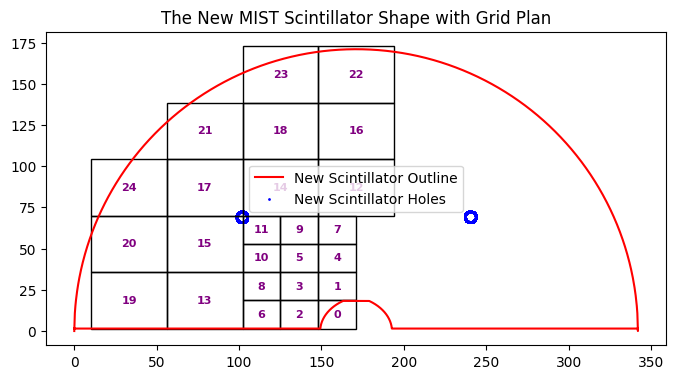

In [205]:
line1 = [np.linspace(0,171-21.75,1000),np.full(1000,1.5)]
xi,yi = -np.sqrt(21.75**2-1.5**2), 1.5
xf,yf = 171-15.69/2,18.3
line2 = [np.linspace(171+xi,xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(xi,-np.sqrt(21.75**2-18.3**2),1000)])]
line3 = [np.linspace(xf,171+15.69/2,1000),np.full(1000,yf)]

xf,yf = np.sqrt(21.75**2-1.5**2), 1.5
xi,yi = 171+15.69/2,18.3
line4 = [np.linspace(xi,171+xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(np.sqrt(21.75**2-18.3**2),xf,1000)])]
line5 = [np.linspace(171+21.75,342,1000),np.full(1000,1.5)]

line6 = [np.linspace(0,342,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(-171,171,1000)])]

new_scint = np.concatenate((line1, line2, line3, line4, line5, np.flip(line6, axis=1)), axis=1)

r = 3.3
circ = np.transpose(np.array([r * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


fig, ax = plt.subplots(figsize=(8, 8))
patches = []

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(171/height)
cols = round(342/width)
centring_correction = (cols*width - 342)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        # Determine if we are in the middle-third horizontally and bottom-third vertically
        if (col > cols/centre_range and col < (round(centre_range/2))*cols/centre_range) and (row < rows/centre_range):
            
            # Base offsets for this specific grid cell
            x_base = col * width - centring_correction
            y_base = row * height + 1.5
            
            w_sub = width / 2
            h_sub = height / 2
            
            # Bottom-left sub-rectangle
            patches.append(Rectangle((x_base, y_base), w_sub, h_sub))
            # Bottom-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base), w_sub, h_sub))
            # Top-left sub-rectangle
            patches.append(Rectangle((x_base, y_base + h_sub), w_sub, h_sub))
            # Top-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base + h_sub), w_sub, h_sub))
        else:
            patches.append(Rectangle((col * width - centring_correction, row * height + 1.5), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([171, 1.5]), 170
new_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    if x_c > 171:
        continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    new_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

# Sort by distance from target center
new_box_data.sort(key=lambda item: item['distance'])

# --- 3. PLOT AND LABEL ---
plt.title("The New MIST Scintillator Shape with Grid Plan")
plt.plot(new_scint[0], new_scint[1], label="New Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="New Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(new_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

(999, 2) (1, 2)
-10.280000000000001
20
Box 0 has 100.00% overlap with the scintillator
Box 1 has 100.00% overlap with the scintillator
Box 2 has 100.00% overlap with the scintillator
Box 3 has 100.00% overlap with the scintillator
Box 4 has 100.00% overlap with the scintillator
Box 5 has 100.00% overlap with the scintillator
Box 6 has 100.00% overlap with the scintillator
Box 7 has 100.00% overlap with the scintillator
Box 8 has 100.00% overlap with the scintillator
Box 9 has 100.00% overlap with the scintillator
Box 10 has 100.00% overlap with the scintillator
Box 11 has 100.00% overlap with the scintillator
Box 12 has 100.00% overlap with the scintillator
Box 13 has 100.00% overlap with the scintillator
Box 14 has 100.00% overlap with the scintillator
Box 15 has 100.00% overlap with the scintillator
Box 16 has 100.00% overlap with the scintillator
Box 17 has 100.00% overlap with the scintillator
Box 18 has 100.00% overlap with the scintillator
Box 19 has 100.00% overlap with the scin

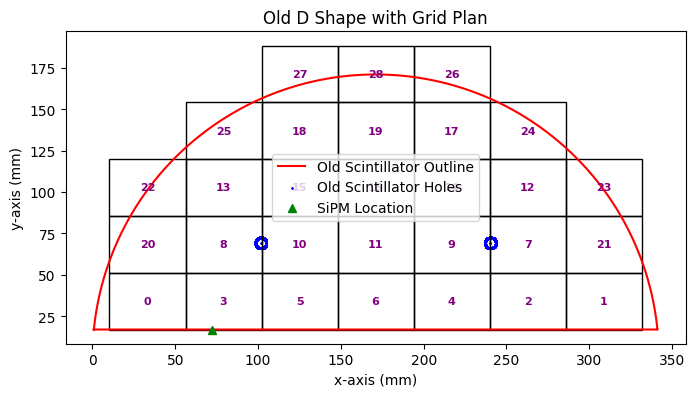

Number of boxes: 29


In [206]:
from shapely.geometry import Polygon, box

def circle(radius):
   circ = np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 999)])
   centre = np.array([np.array([0,0])])
   print(circ.shape,centre.shape)
   return np.transpose(np.concatenate((circ,centre),axis=0))

R = 171
h = 17

xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
X_centre = np.sqrt(R**2-h**2)+xi

line1 = [np.linspace(xi,xf,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(xi-R,xf-R,1000)])]
line2 = [np.linspace(xf,xi,1000),np.full(1000,h)]

old_scint = np.concatenate((line1, line2), axis=1)

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)

old_scint_shape = Polygon(shell=np.transpose(old_scint), holes=[np.transpose(line7), np.transpose(line8)])
old_scint_shape_wout_holes = Polygon(shell=np.transpose(old_scint))

SiPM_loc = [65+7,h]

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - X_centre*2)/2
print(centring_correction)

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R
old_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w
    y_shift = y + h

    # Out of circular boundary check
    if np.linalg.norm(np.array([x, y_shift]) - target_center) > target_range or np.linalg.norm(np.array([x_shift, y_shift]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    overlap = old_scint_shape_wout_holes.intersection(box(x,y,x+w,y+h))
    # print(f'Overlapping area: {overlap.area} => {overlap.area/w/h*100:.2f}% overlap')
    
    old_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance,
        'weighting': overlap.area/w/h # Proportion of overlapping area of box
    })

print(len(old_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
old_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Add in additional, custom boxes (grid expansion requested by Carsten)
for below in [0,1,20,21,12,13,17,18,19]:
    x,y = old_box_data[below]['xy']
    y += h # Move up one box
    distance = np.linalg.norm(np.array([x+w/2, y+h/2]) - target_center)
    overlap = old_scint_shape_wout_holes.intersection(box(x,y,x+w,y+h))
    old_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x+w/2, y+h/2),
        'distance': distance,
        'weighting': overlap.area/w/h # Proportion of overlapping area of box
    })

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (old_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("Old D Shape with Grid Plan")
plt.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(old_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    # print(f"Box {box_id} has centre at ({x_c}, {y_c})")
    print(f'Box {box_id} has {data['weighting']*100:.2f}% overlap with the scintillator')
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
plt.legend()
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
# plt.ylim(0,342)
plt.show()

print(f"Number of boxes: {len(old_box_data)}")

(999, 2) (1, 2)
20


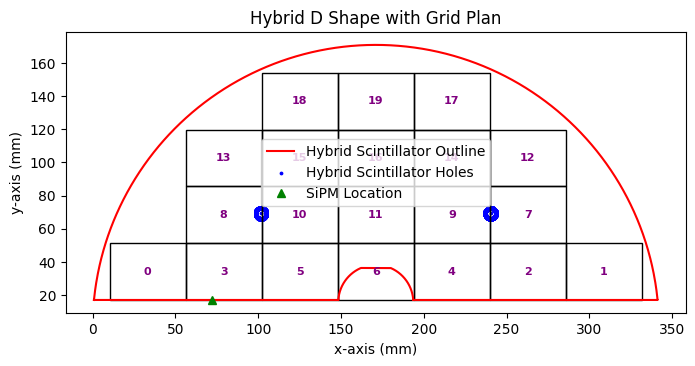

Number of boxes: 20


In [207]:
def circle(radius):
   circ = np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 999)])
   centre = np.array([np.array([0,0])])
   print(circ.shape,centre.shape)
   return np.transpose(np.concatenate((circ,centre),axis=0))

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


45.2, 19.64, 17.1
r_0 = 21.75
h_0 = 18.4
h_m = 19.64
l_0 = 15.69
l_min, l_max = 16.94, 19.64
w_0 = 2*(np.sqrt(r_0**2-1.5**2))
w_m = 45.2
r_0 = 21.75

delta = 0.036*25.4
w = w_0+2*delta
h = h_0+delta
r = r_0+delta
l = 2*np.sqrt(r**2-h**2)

R = 171
H = 17
d = 1.5
SiPM_loc = [65+7,H]

xi,xf = -np.sqrt(R**2-H**2) + R, np.sqrt(R**2-H**2) + R,
W = xf-xi
c = W/2+xi
line1 = [np.linspace(xi,c-w/2,1000),np.full(1000,H)]
line2 = [np.linspace(c+w/2,xf,1000),np.full(1000,H)]

line3 = [np.linspace(xf,xi,1000),np.array([np.sqrt(R**2-x**2) for x in np.linspace(xf-R,xi-R,1000)])]

start,stop = np.sqrt(r**2-d**2), np.sqrt(r**2-(h+d)**2),
line4 = [np.linspace(c-start,c-stop,1000),np.array([np.sqrt(r**2-x**2)+H-d for x in np.linspace(start,stop,1000)])]
line5 = [np.linspace(c+start,c+stop,1000)[::-1],np.array([np.sqrt(r**2-x**2)+H-d for x in np.linspace(start,stop,1000)])[::-1]]
line6 = [np.linspace(c-stop,c+stop,1000),np.full(1000,H+h)]


hybrid_scint = np.concatenate((line1, line4, line6, line5, line2, line3), axis=1)

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

R,h = 171, 17
xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
X_centre = np.sqrt(R**2-h**2)+xi

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - X_centre*2)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        dist = np.linalg.norm([x_c,y_c] - target_center)
        patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R
hybrid_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w
    y_shift = y + h

    # Out of circular boundary check
    if np.linalg.norm(np.array([x, y_shift]) - target_center) > target_range or np.linalg.norm(np.array([x_shift, y_shift]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    hybrid_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

print(len(hybrid_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
hybrid_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (hybrid_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("Hybrid D Shape with Grid Plan")
plt.plot(hybrid_scint[0], hybrid_scint[1], label="Hybrid Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Hybrid Scintillator Holes", s=3, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(hybrid_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
plt.legend()
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
# plt.ylim(0,342)
plt.show()

print(f"Number of boxes: {len(hybrid_box_data)}")

In [208]:
id=0
print("          | Horizontal Distance |   Vertical distance   |  Size of  |          |  Time  |")
print("    ID    | from Left Edge (cm) | from Bottom Edge (cm) | Rectangle | Rotation | Needed |")
print("----------+---------------------+-----------------------+-----------+----------+--------|")

for box_i in old_box_data:
    x, y = box_i['xy']
    w, h = box_i['w'], box_i['h']
    rot = False
    if w == width:
        size='Large'
    elif w == width/2:
        size='Small'
    elif w == height/2:
        size='Small'
        rot=True
    else:
        size='Unknown'
    print(f" {id:8d} | {x/10:19.1f} | {(y-17)/10:21.1f} | {size:>9} | {"90°" if rot else "0°":>8} | {1/box_i['weighting']*100:>6.1f}% |")
    id+=1

          | Horizontal Distance |   Vertical distance   |  Size of  |          |  Time  |
    ID    | from Left Edge (cm) | from Bottom Edge (cm) | Rectangle | Rotation | Needed |
----------+---------------------+-----------------------+-----------+----------+--------|
        0 |                 1.0 |                   0.0 |     Large |       0° |  100.0% |
        1 |                28.6 |                   0.0 |     Large |       0° |  100.0% |
        2 |                24.0 |                   0.0 |     Large |       0° |  100.0% |
        3 |                 5.6 |                   0.0 |     Large |       0° |  100.0% |
        4 |                19.4 |                   0.0 |     Large |       0° |  100.0% |
        5 |                10.2 |                   0.0 |     Large |       0° |  100.0% |
        6 |                14.8 |                   0.0 |     Large |       0° |  100.0% |
        7 |                24.0 |                   3.4 |     Large |       0° |  100.0% |
  

### Scintillator Placements:

### Convert data into detector efficiency and response dictionaries

In [209]:
from pathlib import Path
import sys
project_root = Path.cwd().parents[1]
sys.path.insert(0,  str(project_root / 'src'))
from data_processing import Data
from fit_analysis import FitResult

from detector_region import DetectorRegion

n_chs = 4

# Create Data objects from ROOT files
data_dir = Path.cwd() / 'data'
data_dict = {}
for pdir in data_dir.iterdir():
   if pdir.name[0:4] != 'test': continue
   # print(f"Creating Data object for {pdir}")
   if not pdir.is_dir():
      # print(f"Skipping {pdir}")
      continue
   pdir_raw = pdir / 'RAW'
   # print(pdir_raw)
   
   ch_data =[]
   skip=False
   for ch in range(n_chs):
      token = f'DataR_CH{ch}@DT5751_1616'
      matching_files = [f for f in pdir_raw.iterdir() if f.is_file() and token in f.name]
      if len(matching_files) == 1:
         _s = [index for index, char in enumerate(pdir.name) if char == '_']
         id = pdir.name[_s[0]+1:] if len(_s)==1 else pdir.name[_s[0]+1:_s[1]]
         if id=='6': 
            print(f'id==6. Skipping...')
            skip=True
            break
         if id=='60': 
            print(f'id==60. Changing to 6...')
            id='6'
         ch_data.append(Data(id=id))
         try:
            ch_data[-1].load_file(matching_files[0], lowmem=False)
         except FileExistsError as e:
            print(ch, pdir)
            raise e
      else:
         print(f'No file found with token: DataR_CH{ch}@DT5751_1616')
            
   if skip: continue
   # _s = [index for index, char in enumerate(pdir.name) if char == '_']
   # id = pdir.name[_s[0]+1:] if len(_s)==1 else pdir.name[_s[0]+1:_s[1]]
      
   try:
      existing = data_dict[id]
   except KeyError:
      # id = ch_data[i].id
      existing = [Data(id) for ch in range(n_chs)]
      for i in range(len(existing)): existing[i].channel = i
   data_dict[id] = [ch_data[i] + existing[i] for i in range(n_chs)]

for key,test in data_dict.items():
   print(key)
   for ch in test:
      print(ch)

print(f'\n\nYou have taken data for {len(data_dict.keys())/len(old_box_data)*100:.2f}% of detector regions!')
days_remaining = max((len(old_box_data)-len(data_dict.keys()))/2,0)
print(f'{int(days_remaining/5)} weeks, {days_remaining%5} days remaining')

id==6. Skipping...
id==60. Changing to 6...
id==60. Changing to 6...
id==60. Changing to 6...
id==60. Changing to 6...
4
            0 |                  561 |      11646 s |   0.05 ± 0.00 (events/s) |                  215 
            1 |                  511 |      11646 s |   0.04 ± 0.00 (events/s) |                    0 
            2 |                  512 |      11646 s |   0.04 ± 0.00 (events/s) |                    0 
            3 |                  561 |      11646 s |   0.05 ± 0.00 (events/s) |                   86 
13
            0 |                 1849 |      56977 s |   0.03 ± 0.00 (events/s) |                   40 
            1 |                 1768 |      56977 s |   0.03 ± 0.00 (events/s) |                   31 
            2 |                 1768 |      56977 s |   0.03 ± 0.00 (events/s) |                   31 
            3 |                 1849 |      56977 s |   0.03 ± 0.00 (events/s) |                  517 
14
            0 |                 1010 |      27311

NOTE:\
Events get merged, not appended when adding together root files with `hadd` (which is what I did). This means that the duration and event rate of a sample are not preserved. This doesn't affect this analysis, but it is still worth noting in case I want to use the data for other purposes. The following folders were created using `hadd`:
- `test_0`
- `test_2`
- `test_6`

In [210]:
t = data_dict['0'][0].db['Time']
for i in range(len(t)-1):
   if t[i+1] < t[i]:
      print('Uh-oh')

In [211]:
# Filter out noise by eliminating events that don't have triple coincidence

def explore_noise(coincidence_level, acceptance_time=1.6e-8, plots = False):

   new_tests = []
   master_nmt = []
   for id, test in data_dict.items():
      print(id,test[0].id)
      masks = [[] for ch in test]
      masks_1 = [[] for ch in test]
      masks_2 = [[] for ch in test]
      idxs = [0 for ch in test]
      ch_times = [ch.db['Time'] for ch in test]
      dts, noise_counts = [],[0 for ch in test]
      no_missed_times,negative_dts,l_negative_dts = [],[],[]
      for t in ch_times[0]: # Channels 0 and 3 are the coincidence channels => always have all events
         noise = True
         # Check for coincidence in chs 1 and 2
         if int(id)<7 or int(id)>=60: ti,tf = ch_times[3][idxs[3]],ch_times[0][idxs[0]] # Channel 3 is the top scintillator while channel 0 is at the bottom for tests 0-6
         elif int(id)>=7: tf,ti = ch_times[3][idxs[3]],ch_times[0][idxs[0]] # Channel 3 is the bottom scintillator while channel 0 is at the top for tests 7-28
         dt = tf - ti
         # if dt>0: print(dt)
         dts.append(dt)

         # t0 = ch_times[0][idxs[0]],
         # print((ch_times[0][idxs[0]]-t0)*1e9,(ch_times[1][idxs[1]]-t0)*1e9,(ch_times[2][idxs[2]]-t0)*1e9,(ch_times[3][idxs[3]]-t0)*1e9, test[0].db['Height'][idxs[0]], test[3].db['Height'][idxs[3]])
         # if (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 < 16) and (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 > 16): 
         #    print("!!")
         #    print(test[3].db['Energy'][idxs[3]])
         # if (np.abs(ch_times[2][idxs[2]]- ch_times[3][idxs[3]])*1e9 < 16) and (np.abs(ch_times[2][idxs[2]]- ch_times[3][idxs[3]])*1e9 > 16): 
         #    print("!!")
         #    print(test[3].db['Energy'][idxs[3]])


         # t_c = ch_times[3][idxs[3]]+dts[idxs[3]]/2
         # if id=='3':
         #    print(len(ch_times[3])-1-idxs[3],len(ch_times[1])-1-idxs[1])
         # try:
         #    ch_times[1][idxs[1]]
         # except:
         #    print(f"{ch_times[3][-1]} versus {ch_times[2][-1]}")
         #    print(f"Channel 1 is on index {idxs[1]}/{len(ch_times[1])-1} and Channel 2 is on {idxs[2]}/{len(ch_times[2])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")

         # if id == '3':
            # print(np.abs(t_c - ch_times[1][idxs[1]]))
         # blud = False
         # if np.abs(t_c - ch_times[1][idxs[1]]) > acceptance_time:
         #    # print("!^!", noise_counts[3] - noise_counts[1], idxs[3] - idxs[1])
         #    blud = True
         # if (np.abs(ti - ch_times[1][idxs[1]]) > 1.6e-8 or np.abs(tf - ch_times[1][idxs[1]]) > 1.6e-8) and not blud:
         #    # print("!!^!!")
         #    print(np.abs(t_c - ch_times[1][idxs[1]]))
         #    print(tf-ti,tf-ch_times[1][idxs[1]])
         # if (np.abs(ti - ch_times[1][idxs[1]]) > 1.6e-8 and np.abs(tf - ch_times[1][idxs[1]]) > 1.6e-8) and not blud:
         #    print('Aha!')

         # Determine if either of channels 1 and 2 were triggered
         acceptable = [ti - acceptance_time, tf + acceptance_time]
         try:
            ch_1_event = True if (ch_times[1][idxs[1]]>acceptable[0] and ch_times[1][idxs[1]]<acceptable[1]) else False
         except:
            if len(ch_times[3])-1==idxs[3]:
               ch_1_event = False
            else:
               raise IndexError(f"Channel 1 is on index {idxs[1]}/{len(ch_times[1])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")
         try:
            ch_2_event = True if (ch_times[2][idxs[2]]>acceptable[0] and ch_times[2][idxs[2]]<acceptable[1]) else False
         except:
            if len(ch_times[3])-1==idxs[3]:
               ch_2_event = False
            else:
               raise IndexError(f"Channel 2 is on index {idxs[2]}/{len(ch_times[2])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")

         # Determine whether the event is noise based on coincidence level
         if 2 + ch_1_event + ch_2_event >= coincidence_level: noise = False

         # Update masks to account for noise
         if not noise:
            masks[0].append(True)
            if ch_1_event: masks[1].append(True)
            if ch_2_event: masks[2].append(True)
            masks[3].append(True)
            masks_1[0].append(False)
            if ch_1_event: masks_1[1].append(False)
            if ch_2_event: masks_1[2].append(False)
            masks_1[3].append(False)
            masks_2[0].append(False)
            if ch_1_event: masks_2[1].append(False)
            if ch_2_event: masks_2[2].append(False)
            masks_2[3].append(False)
         else:
            masks[0].append(False)
            if ch_1_event: masks[1].append(False)
            if ch_2_event: masks[2].append(False)
            masks[3].append(False)
            noise_counts[0] += 1
            if ch_1_event: noise_counts[1] += 1
            if ch_2_event: noise_counts[2] += 1
            noise_counts[3] += 1

            if ch_1_event:
               masks_1[0].append(True)
               if ch_1_event: masks_1[1].append(True)
               if ch_2_event: masks_1[2].append(True)
               masks_1[3].append(True)
            else:
               masks_1[0].append(False)
               if ch_1_event: masks_1[1].append(False)
               if ch_2_event: masks_1[2].append(False)
               masks_1[3].append(False)
            if ch_2_event:
               masks_2[0].append(True)
               if ch_1_event: masks_2[1].append(True)
               if ch_2_event: masks_2[2].append(True)
               masks_2[3].append(True)
            else:
               masks_2[0].append(False)
               if ch_1_event: masks_2[1].append(False)
               if ch_2_event: masks_2[2].append(False)
               masks_2[3].append(False)

         # Update no_missed_times
         if ch_1_event and ch_2_event:
            no_missed_times.append(np.array([ch_times[ch][idxs[ch]] for ch in range(n_chs)]))
         
         if dt<0:
            chs_seen = 2
            if ch_1_event: chs_seen+=1
            if ch_2_event: chs_seen+=1
            negative_dts.append(chs_seen)
            if dt<-5e-9:
               l_negative_dts.append(chs_seen)

         # Update indexing
         idxs[0] += 1
         if ch_1_event: idxs[1] += 1
         if ch_2_event: idxs[2] += 1
         idxs[3] += 1

         
      masks = [np.array(mask) for mask in masks]
      masks_1 = [np.array(mask) for mask in masks_1]

      if plots:
         fig, axs = plt.subplots(1,2,figsize=(8,4))
         fig.suptitle("Small-Peak Channel 0 Events which Were Caught by Channel 3 but\nWere Missed in Channels 1 and 2")
         for i in range(2):
               ch = [0,3][i]
               axs[i].set_title(f"Channel {ch}")
               axs[i].set_xlabel("Time (s)")
               axs[i].set_ylabel("Signal (mV)")
               waves = test[ch].db['Signal'][~masks[0]]
               print(len(waves))
               small_peak_waves = [wave for wave in waves if np.max(wave)<20]
               print(len(small_peak_waves))
               for k in range(len(small_peak_waves)):
                  small_peak_wave = small_peak_waves[k]
                  ns = np.linspace(0,len(small_peak_wave),len(small_peak_wave))
                  axs[i].plot(ns, small_peak_wave,label=f"Wave {k}")
         # plt.legend()
         plt.tight_layout()
         plt.show()

         fig, axs = plt.subplots(1,2,figsize=(8,4))
         fig.suptitle("Histogram of the Time Difference Between Events in Channel 0 with a Small\nPeak that Were Missed in Channel 1 and 2 but not Channel 3")
         for i in range(2):
               ch = [0,3][i]
               axs[i].set_title(f"Channel {ch}")
               axs[i].set_xlabel("Time Difference (ns)")
               axs[i].set_ylabel("Counts")
               waves = test[ch].db['Signal'][~masks[0]]
               small_peak_dts = waves = [dts[i]*1e9 for i in range(len(waves)) if np.max(waves[i])<20]
               axs[i].hist(small_peak_dts)
         # plt.legend()
         plt.tight_layout()
         plt.show()

         # fig, axs = plt.subplots(2,2,figsize=(8,8))
         # fig.suptitle("Channel 1 noise events")
         # for i in range(2):
         #    for j in range(2):
         #       ch = i*2+j
         #       axs[i][j].set_title(f"Channel {ch}")
         #       axs[i][j].set_xlabel("Time (s)")
         #       axs[i][j].set_ylabel("Signal (mV)")
         #       waves = test[ch].db['Signal'][masks_1[ch]]
         #       for k in range(len(waves)):
         #          wave = waves[k]
         #          ns = np.linspace(0,len(wave),len(wave))
         #          axs[i][j].plot(ns, wave,label=f"Wave {k}")
         # plt.legend()
         # plt.tight_layout()
         # plt.show()

         # fig, axs = plt.subplots(2,2,figsize=(8,8))
         # fig.suptitle("Channel 2 noise events")
         # for i in range(2):
         #    for j in range(2):
         #       ch = i*2+j
         #       axs[i][j].set_title(f"Channel {ch}")
         #       axs[i][j].set_xlabel("Time (s)")
         #       axs[i][j].set_ylabel("Signal (mV)")
         #       waves = test[ch].db['Signal'][masks_2[ch]]
         #       for k in range(len(waves)):
         #          wave = waves[k]
         #          ns = np.linspace(0,len(wave),len(wave))
         #          axs[i][j].plot(ns, wave,label=f"Wave {k}")
         # plt.legend()
         # plt.tight_layout()
         # plt.show()

      no_missed_times = np.transpose(np.array(no_missed_times))

      new_test = []
      for ch in range(len(test)):
         new_test.append(test[ch] % masks[ch]) # Apply mask to all data

      dts = np.array(dts)
      print(f"{id} - Non-positive travel times from channel 0 to channel 3: {len(dts[np.array(dts)<0])/len(dts)*100:.2f}% ({len(dts[np.array(dts)<0])} events)")
      for ch in range(n_chs):
         print(f'\tChannel {ch} Number of events identified as noise: {noise_counts[ch]:>2} ({noise_counts[ch]/len(ch_times[ch])*100:.2f}%)')
      print(f'\t{len(new_test[0].db['Time'])} =? {len(new_test[1].db['Time'])} =? {len(new_test[2].db['Time'])} =? {len(new_test[3].db['Time'])}')
      print(f'\tnmt: {no_missed_times.shape}')
      print(f'\t{len(negative_dts)} events had a negative travel time between channel 0 and channel 3. {negative_dts.count(2)/len(negative_dts)*100:.2f}% seen by only outers, {negative_dts.count(3)/len(negative_dts)*100:.2f}% seen by exactly 3, {negative_dts.count(4)/len(negative_dts)*100:.2f}% seen by all 4')
      print(f'\t{len(l_negative_dts)} events had a travel time between channel 0 and channel 3 less than -5 ns. {l_negative_dts.count(2)/len(l_negative_dts)*100:.2f}% seen by only outers, {l_negative_dts.count(3)/len(l_negative_dts)*100:.2f}% seen by exactly 3, {l_negative_dts.count(4)/len(l_negative_dts)*100:.2f}% seen by all 4')
      print()

      new_tests.append(new_test)
      master_nmt.append(no_missed_times)
   
   return new_tests, master_nmt

# explore_noise(coincidence_level = 4,acceptance_time = 4.5e-8,plots=True)

We run the following lines of code to update the pointers: 
```python
# Update indexing
idxs[0] += 1
if ch_1_event: idxs[1] += 1
if ch_2_event: idxs[2] += 1
idxs[3] += 1   
```
Since `idxs[1]` and `idxs[2]` end up exactly one events ahead of channels 0 and 3, and are only updated when a channel event is detected, we can infer that there is exactly one event too many being detected in these channels.

If channel 1 has "seen an event", that means that the current time being pointed to is close to the times of the event seen by channels 0 and 3.

If channel 1 has falsely seen an event, then the time being pointed to is close to the times of the events seen by channels 0 and 3, but it does not belong with them. In this case, the pointers will be advanced forwards, meaning that it is unlikely the next event is detected as an actual event. Thus this can only cause a crash if it happen at the very end? NO

I believe that the only explanation is that in such a case, the last event detected by channels 0 and 3 is not detected by channel 1 or channel 2, and so the pointers are advanced to what should be the last event, but this is missing from the channel 0 and channel 2 data, causing a crash.

In [212]:
print(width,height)
test = data_dict['3']

print(min(np.diff(test[0].db['Time'])))
print(max(np.diff(test[0].db['Time'])))
print(min(np.diff(test[1].db['Time'])))
print(max(np.diff(test[1].db['Time'])))
print(min(np.diff(test[2].db['Time'])))
print(max(np.diff(test[2].db['Time'])))
print(min(np.diff(test[3].db['Time'])))
print(max(np.diff(test[3].db['Time'])))

45.92 34.28
0.0020544508151942864
191.83158736193582
0.002054449367278721
205.85189630724562
0.0020544463768601418
205.8518963054994
0.0020544513754430227
191.83158736125006


3\
            0 |                 2385 |      58991 s |   0.04 ± 0.00 (events/s) |                   28 \
            1 |                 2214 |      58986 s |   0.04 ± 0.00 (events/s) |                   92 \
            2 |                 2214 |      58986 s |   0.04 ± 0.00 (events/s) |                   56 \
            3 |                 2385 |      58991 s |   0.04 ± 0.00 (events/s) |                  427 

These plots, taken with the analysis performed in `timing_distribution.ipynb`, demonstrate that triple coincidence is sufficient and that the "noise" events picked up for channels 1 and 2 with coincidence level 4 are not actually noise, but rather events that are not detected by the other channel, which shows that we can actually measure detector efficiency pretty well!

In [213]:
def filter_noise(ddict):
   new_tests,nmt = [],[]
   for key, dlst in ddict.items():
      nmt_i = []
      t0,t1,t2,t3 = dlst[0].db['Time']*1e9,dlst[1].db['Time']*1e9,dlst[2].db['Time']*1e9,dlst[3].db['Time']*1e9
      i0,i1,i2,i3, masks = 0,0,0,0,[[],[],[],[]]
      while i0<len(t0):
         try:
            ch1_event = np.abs(t1[i1]-t0[i0]) < 1000
         except IndexError:
            print(f'[WARNING] ({key}) Channel 1 has no more triggers, but there is still {len(t0)-i0} more Channel 0 triggers')
            if len(t0)-i0 <= 2:
               ch1_event = False
            else:
               print(f'{i0}/{len(t0)-1}')
               print(f'{i2}/{len(t2)-1}')
               raise IndexError(f'{key} - You have gone beyond the end of Channel 1: index {i1}, length {len(t1)}')
         try:
            ch2_event = np.abs(t2[i2]-t0[i0]) < 1000
         except IndexError:
            print(f'[WARNING] ({key}) Channel 2 has no more triggers, but there is still {len(t0)-i0} more Channel 0 triggers')
            if len(t0)-i0 <= 2:
               ch2_event = False
            else:
               print(f'{i0}/{len(t0)-1}')
               raise IndexError(f'{key} - You have gone beyond the end of Channel 2: index {i1}, length {len(t1)}')

         # Update nmt_i if both ch1 and ch2 saw an event
         if ch1_event and ch2_event:
            nmt_i.append(np.array([t0[i0],t1[i1],t2[i2],t3[i3]]))

         # Update indexing and mask
         mask_val = ch1_event or ch2_event
         i0 += 1
         masks[0].append(mask_val)
         if ch1_event: 
            i1 += 1
            masks[1].append(mask_val)
         if ch2_event: 
            i2 += 1
            masks[2].append(mask_val)
         i3 += 1
         masks[3].append(mask_val)


      nmt.append(np.transpose(np.array(nmt_i)))
      masks = [np.array(masks[i]) for i in range(len(masks))]

      print(key)
      for ch in range(4):
         # print(dlst[ch])
         # print(len(dlst[ch].db['Time']),len(masks[ch]))
         print(f'\t{ch}: {len(dlst[ch].db['Time']):<4}-->{len(dlst[ch].db['Time'][masks[ch]]):>4} {len(dlst[ch].db['Time'])/len(dlst[0].db['Time'][masks[0]])*100:6.2f}%')

      new_test = []
      for ch in range(len(dlst)):
         new_test.append(dlst[ch] % masks[ch]) # Apply mask to all data    
      new_tests.append(new_test)
      # for ch in range(4):
      #    print((len(new_test[ch].db['Time'])))
      #    print(new_test[ch].NEvents)  

   return new_tests, nmt

new_tests,nmt = filter_noise(data_dict)

4
	0: 561 --> 516 108.72%
	1: 511 --> 511  99.03%
	2: 512 --> 512  99.22%
	3: 561 --> 516 108.72%
13
	0: 1849-->1770 104.46%
	1: 1768-->1768  99.89%
	2: 1768-->1768  99.89%
	3: 1849-->1770 104.46%
14
	0: 1010--> 972 103.91%
	1: 971 --> 971  99.90%
	2: 970 --> 970  99.79%
	3: 1010--> 972 103.91%
22
	0: 901 --> 606 148.68%
	1: 549 --> 549  90.59%
	2: 566 --> 566  93.40%
	3: 901 --> 606 148.68%
25
	0: 2048-->1871 109.46%
	1: 1863-->1863  99.57%
	2: 1809-->1809  96.69%
	3: 2048-->1871 109.46%
1
	0: 777 --> 741 104.86%
	1: 740 --> 740  99.87%
	2: 741 --> 741 100.00%
	3: 777 --> 741 104.86%
[WARNING] (24) Channel 1 has no more triggers, but there is still 1 more Channel 0 triggers
[WARNING] (24) Channel 2 has no more triggers, but there is still 1 more Channel 0 triggers
24
	0: 2403-->1669 143.98%
	1: 1497-->1497  89.69%
	2: 1581-->1581  94.73%
	3: 2403-->1669 143.98%
[WARNING] (23) Channel 1 has no more triggers, but there is still 2 more Channel 0 triggers
[WARNING] (23) Channel 1 has no m

In [214]:
new_tests,nmt = filter_noise(data_dict)

i=0
for key in data_dict.keys():
   # print(key,data_dict[key][0].id, nmt[i].shape)
   # data_dict[key]= (data_dict[key],nmt[i])
   print(key,new_tests[i][0].id, nmt[i].shape)
   data_dict[key]= (new_tests[i],nmt[i])
   i+=1

4
	0: 561 --> 516 108.72%
	1: 511 --> 511  99.03%
	2: 512 --> 512  99.22%
	3: 561 --> 516 108.72%
13
	0: 1849-->1770 104.46%
	1: 1768-->1768  99.89%
	2: 1768-->1768  99.89%
	3: 1849-->1770 104.46%
14
	0: 1010--> 972 103.91%
	1: 971 --> 971  99.90%
	2: 970 --> 970  99.79%
	3: 1010--> 972 103.91%
22
	0: 901 --> 606 148.68%
	1: 549 --> 549  90.59%
	2: 566 --> 566  93.40%
	3: 901 --> 606 148.68%
25
	0: 2048-->1871 109.46%
	1: 1863-->1863  99.57%
	2: 1809-->1809  96.69%
	3: 2048-->1871 109.46%
1
	0: 777 --> 741 104.86%
	1: 740 --> 740  99.87%
	2: 741 --> 741 100.00%
	3: 777 --> 741 104.86%
[WARNING] (24) Channel 1 has no more triggers, but there is still 1 more Channel 0 triggers
[WARNING] (24) Channel 2 has no more triggers, but there is still 1 more Channel 0 triggers
24
	0: 2403-->1669 143.98%
	1: 1497-->1497  89.69%
	2: 1581-->1581  94.73%
	3: 2403-->1669 143.98%
[WARNING] (23) Channel 1 has no more triggers, but there is still 2 more Channel 0 triggers
[WARNING] (23) Channel 1 has no m

In [215]:
# Create DetectorRegion objects
for key, test in data_dict.items():
   print(len(test))
   for ch in range(n_chs):
      print(test[0][ch],'\n',len(test[1][ch]))
      print(test[1][ch][0:5])
   data_dict[key] = [DetectorRegion(key, test[0][ch],test[1][ch]) for ch in range(n_chs)]

2
           -1 |                  516 |      11646 s |   0.04 ± 0.00 (events/s) |                  202  
 507
[3.17404607e+09 3.89210603e+10 1.13801951e+11 1.16936572e+11
 1.81794569e+11]
           -1 |                  511 |      11646 s |   0.04 ± 0.00 (events/s) |                    0  
 507
[3.17404607e+09 3.89210603e+10 1.13801951e+11 1.16936572e+11
 1.81794569e+11]
           -1 |                  512 |      11646 s |   0.04 ± 0.00 (events/s) |                    0  
 507
[3.17404607e+09 3.89210603e+10 1.13801951e+11 1.16936572e+11
 1.81794569e+11]
           -1 |                  516 |      11646 s |   0.04 ± 0.00 (events/s) |                   81  
 507
[3.17404606e+09 3.89210603e+10 1.13801951e+11 1.16936572e+11
 1.81794569e+11]
2
           -1 |                 1770 |      56977 s |   0.03 ± 0.00 (events/s) |                   39  
 1766
[1.10275339e+10 2.46008229e+10 3.96669105e+10 5.18591504e+10
 6.38069872e+10]
           -1 |                 1768 |      56977 s |   0.03

### Detector Response

In [216]:
print(type(old_box_data))
print(type(old_box_data[0]))
print(old_box_data[0])
print(width,height)

<class 'list'>
<class 'dict'>
{'xy': (np.float64(10.280000000000001), 17.0), 'w': 45.92, 'h': 34.28, 'centre': (np.float64(33.24), 34.14), 'distance': np.float64(141.9272954720127), 'weighting': 1.0}
45.92 34.28


In [217]:
ph_mpv_list = []
for ch in range(n_chs):
   ph_mpv_dict = {}
   for key in data_dict.keys():
      test = data_dict[key][ch]
      ph_mpv_dict[int(key)] = test.get_ph_mpv(plot=False)
   ph_mpv_list.append(ph_mpv_dict)

In [ ]:
import matplotlib.cm as cm
import matplotlib.patches as ptch

def make_subplot(ax, title, box_values, full_box_data, vmin, vmax, cmap = 'turbo', xlabel= None, ylabel = None):
   
   box_positions = {}
   for key in box_values.keys():
      if key in range(len(full_box_data)):
         corner = full_box_data[key]['xy']
         box_positions[key] = (float(corner[0]),float(corner[1]))
      
   patch_list = []
   values = []
   for box_id, (x, y) in box_positions.items():
      if box_id in box_values:
         # Create a rectangle patch for the box
         #   rect = Rectangle((x, y), width, height)
         # print(old_scint_shape_wout_holes)
         # print(box)
         # print(box(x,y,x+width,y+height))
         # print(type(old_scint_shape_wout_holes))
         shapely_poly = old_scint_shape_wout_holes.intersection(box(x,y,x+width,y+height))
         mpl_poly = ptch.Polygon(shapely_poly.exterior.coords, closed=True, facecolor='blue')
         patch_list.append(mpl_poly)
         values.append(box_values[box_id])

   p_collection = PatchCollection(patch_list, cmap=cmap, edgecolor='black', linewidth=1)
   p_collection.set_array(np.array(values))
   p_collection.set_clim(vmin,vmax)

   ax.add_collection(p_collection)

   ax.set_title(title)
   ax.set_xlim(0,342)
   ax.set_ylim(0,171)
   if xlabel: ax.set_xlabel(xlabel)
   if ylabel: ax.set_ylabel(ylabel)
   ax.set_aspect('equal')

   ax.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='black')
   ax.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='grey')
   ax.plot(SiPM_loc[0],SiPM_loc[1],label='SiPM Location',color='green',linestyle='',marker='^')
   # ax.legend()
   ax.set_aspect('equal')
   return patch_list

def make_rough_colour_map(box_values, full_box_positional_data, channels=[1,2],title = '',cmap_label = '', cmap = 'turbo'):
   if len(channels) == 1: rows, cols = 1,1 
   elif len(channels) == 2: rows, cols = 1,2
   else: rows, cols = 2,2
   fig, axs = plt.subplots(rows,cols,figsize=(10, 6)) 
   fig.suptitle(title)

   patch_list, p_collections, values = [], [], []
   vmin,vmax = 1e9, 0
   for ch in box_values:
      for key in ch.keys():
         if ch[key] > vmax: vmax = ch[key]
         if ch[key] < vmin: vmin = ch[key]

   for i in range(rows):
      for j in range(cols):
         ch = channels[i*2+j]
         xlabel = 'x-axis (mm)' if i == rows-1 or (rows!=cols and j== cols-1) else None
         ylabel = 'y-axis (mm)' if j == 0 else None
         if rows<2:
            ch_patch_list = make_subplot(axs[j], f'Channel {ch}', box_values[ch], full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         elif cols<2:
            ch_patch_list = make_subplot(axs, f'Channel {ch}', box_values[ch], full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         else:
            ch_patch_list = make_subplot(axs[i,j], f'Channel {ch}', box_values[ch], full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         patch_list += ch_patch_list

   p_collection = PatchCollection(patch_list, cmap=cmap, edgecolor='black', linewidth=1)
   p_collection.set_clim(vmin,vmax)
   plt.tight_layout()
   cbar = fig.colorbar(p_collection, ax=axs)
   cbar.set_label(cmap_label, rotation=270, labelpad=15)
   plt.legend()
   plt.show()

def make_regional_hist(data_list,title,xlabel):
   dm = {k: val for k, val in data_list[1].items() if int(k)<60}.values()
   rc = {k: val for k, val in data_list[2].items() if int(k)<7}.values()
   oc = {k: val for k, val in data_list[2].items() if (int(k)>=7 and int(k)<60)}.values()
   _,bins = np.histogram(list(dm)+list(rc)+list(oc))
   plt.title(title)
   plt.xlabel(xlabel)
   plt.ylabel('Number of Scintillator Subregions')
   plt.hist(dm,histtype='stepfilled',alpha=2/3,bins=bins,label='Diamond-Milled D')
   plt.hist(rc,histtype='stepfilled',alpha=2/3,bins=bins,label='Rough-Cut D')
   plt.hist(oc,histtype='stepfilled',alpha=2/3,bins=bins,label='Optical Cement D')
   plt.legend()
   plt.show()

def make_clean_colour_map(box_values, full_box_positional_data, kinds=['Diamond-Milled','Rough-Cut','Optical Cement'], title = '',cmap_label = '', cmap = 'turbo', vmax_override = None):
   if len(kinds) == 1: rows, cols = 1,1 
   elif len(kinds) == 2: rows, cols = 1,2
   else: rows, cols = 2,2
   fig, axs = plt.subplots(rows,cols,figsize=(10, 6)) 
   fig.suptitle(title)

   patch_list, p_collections, values = [], [], []
   # Obtain vmin and vmax
   vmin,vmax = 1e9, 0
   for ch in box_values:
      for key in ch.keys():
         if key >=60: continue
         if ch[key] > vmax: vmax = ch[key]
         if ch[key] < vmin: vmin = ch[key]
   if vmax_override is not None: vmax = vmax_override
   print(vmin,vmax)

   for i in range(rows):
      for j in range(cols):
         try:
            kind = kinds[i*2+j]
         except IndexError:
            continue
         xlabel = 'x-axis (mm)' if i == rows-1 or len(kinds)==3 else None
         ylabel = 'y-axis (mm)' if j == 0 else None
         if kind == 'Diamond-Milled':
            clean_box_values = box_values[1]
         elif kind=='Rough-Cut':
            clean_box_values = {k: val for k, val in box_values[2].items() if int(k)<7}
         elif kind=='Optical Cement':
            clean_box_values = {k: val for k, val in box_values[2].items() if int(k)>=7}
         else:
            raise KeyError(f'Kind of colour map {kind} does not exist. Accepted kinds: ["Diamond-Milled","Rough-Cut","Optical Cement"]')
         if rows<2:
            ch_patch_list = make_subplot(axs[j], f'{kind} D', clean_box_values, full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         elif cols<2:
            ch_patch_list = make_subplot(axs, f'{kind} D', clean_box_values, full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         else:
            ch_patch_list = make_subplot(axs[i,j], f'{kind} D', clean_box_values, full_box_positional_data, vmin, vmax, cmap=cmap, xlabel=xlabel, ylabel=ylabel)
         patch_list += ch_patch_list

   p_collection = PatchCollection(patch_list, cmap=cmap, edgecolor='black', linewidth=1)
   p_collection.set_clim(vmin,vmax)
   plt.tight_layout()
   cbar = fig.colorbar(p_collection, ax=axs)
   cbar.set_label(cmap_label, rotation=270, labelpad=15)
   if len(kinds) == 3: axs[1,1].remove()
   # plt.legend()
   plt.show()

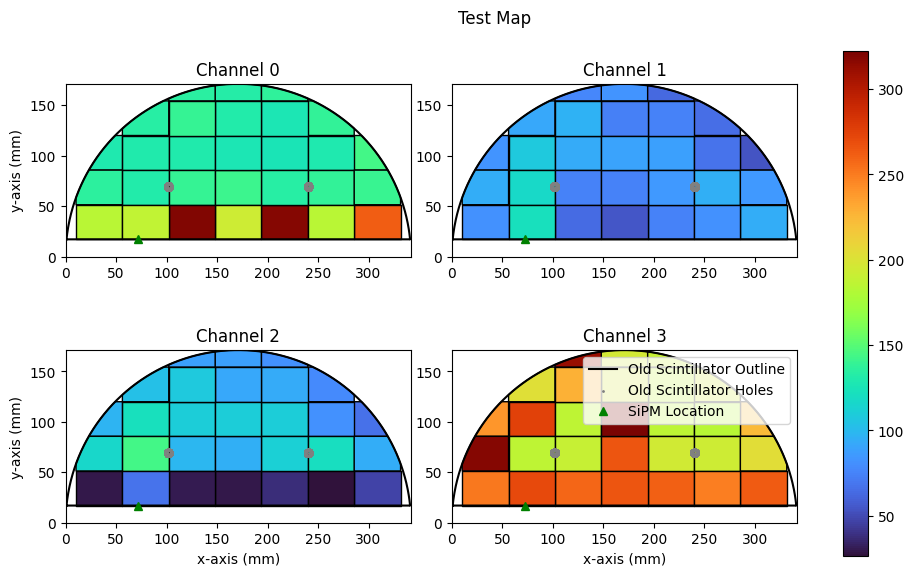

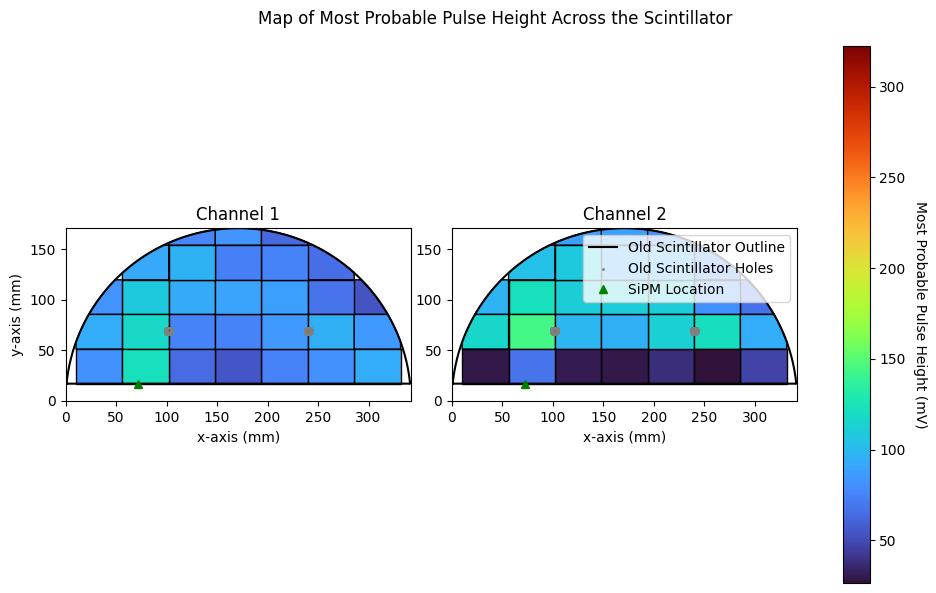

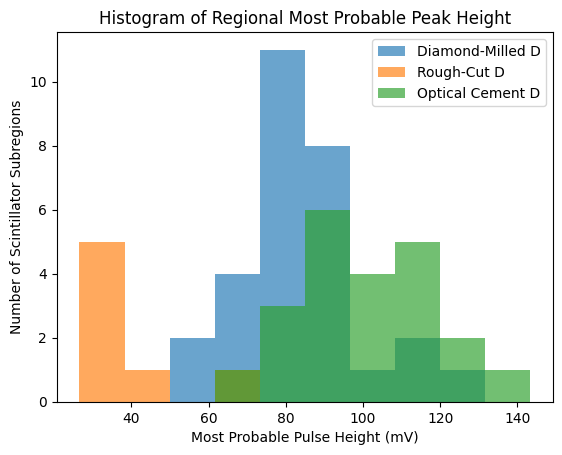

26.51589648234563 322.3981375347605


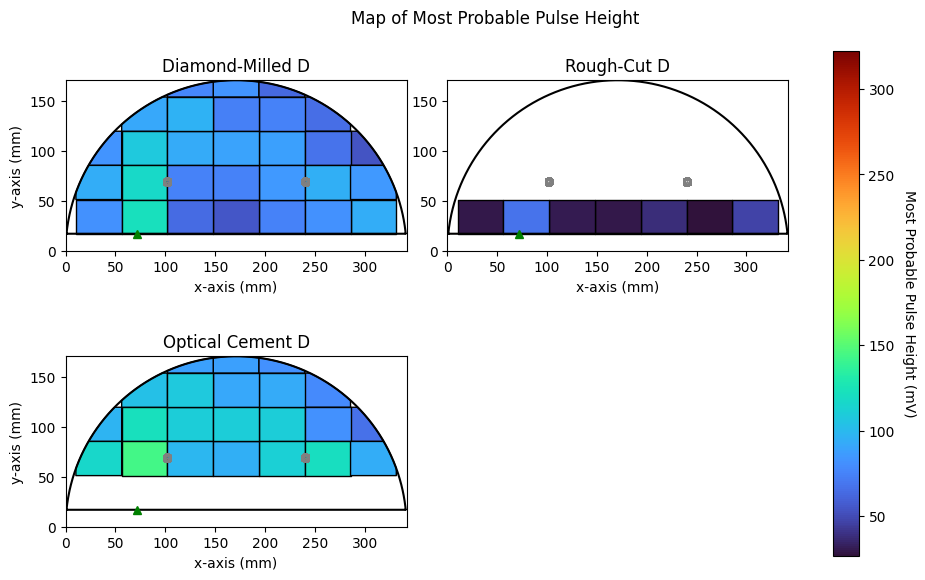

In [219]:

make_rough_colour_map(ph_mpv_list,old_box_data, [0,1,2,3], 'Test Map')
make_rough_colour_map(ph_mpv_list,old_box_data, [1,2], 'Map of Most Probable Pulse Height Across the Scintillator','Most Probable Pulse Height (mV)')

make_regional_hist(ph_mpv_list,'Histogram of Regional Most Probable Peak Height','Most Probable Pulse Height (mV)')
make_clean_colour_map(ph_mpv_list,old_box_data,title='Map of Most Probable Pulse Height',cmap_label='Most Probable Pulse Height (mV)')

### Detector Efficiency

Need to calculate how many of our single inner detector events on the edges are actually only going through one scintillator. Then I can apply a correction factor. To do this, I will simulate the geometry of the edge positions and perform MC to determine the fraction of events that are actually going through one scintillator versus two. This will allow me to correct the measured efficiency accordingly.

In [220]:
# from scipy.optimize import root

# def extrapolate(pt1,pt2,dim,target):
#    vec = pt2-pt1
#    # print(pt1[dim]+-0.1*vec[dim]-target)
#    # print(pt1[dim]+-0*vec[dim]-target)
#    a = root(lambda a,pt1,vec,dim,target: pt1[dim]+a*vec[dim]-target,x0=-0.1,args=(pt1,vec,dim,target)).x
#    # print(pt1,vec,a,pt1+a*vec)
#    return pt1+a*vec

# cardboard = np.array([np.array([2.0,16.1,6.4]),np.array([33.9,16.1,5.8]),np.array([45.9,0.0,5.4]),np.array([0.0,0.0,6.8])])
# v1,v2 = extrapolate(cardboard[0],cardboard[1],0,0),extrapolate(cardboard[1],cardboard[0],0,45.9)
# cardboard_boundary = np.transpose(np.array([v1,v2,cardboard[2],cardboard[3],v1]))

# # print(v2-v1,cardboard[3]-cardboard[2])
# # print(cardboard[3]-v1,cardboard[2]-v2)

# def plane(pt1,pt2,pt3,display=True):
#    u,v = pt2-pt1,pt3-pt1
#    u_x_v = np.cross(u,v)
#    d = -1*np.dot(u_x_v,pt1)
#    if display:
#       print('Plane Equation:')
#       print(f'{u_x_v[0]:.2f}x + {u_x_v[1]:.2f}y + {u_x_v[2]:.2f}z + {d:.2f} = 0')
#    return lambda x,y: -1/u_x_v[2] * (u_x_v[0]*x + u_x_v[1]*y + d), -u_x_v/np.linalg.norm(u_x_v)

# i_hat = (cardboard[1]-cardboard[0])/np.linalg.norm(cardboard[1]-cardboard[0])
# z_from_xy,k_hat = plane(cardboard[0],cardboard[1],cardboard[3])
# j_hat = np.cross(k_hat,i_hat)
# print(i_hat,j_hat,k_hat)
# c_basis = np.array([i_hat,j_hat,k_hat])

# xgrid,ygrid = np.meshgrid(np.linspace(0,cardboard[1,0],1000),np.linspace(0,cardboard[0,1],1000))
# zgrid = z_from_xy(xgrid,ygrid)

# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(xs=np.transpose(cardboard)[0],ys=np.transpose(cardboard)[1],zs=np.transpose(cardboard)[2],label='Measured Points')
# ax.scatter(xs=[v1[0],v2[0]],ys=[v1[1],v2[1]],zs=[v1[2],v2[2]],label='Extrapolated Points')
# ax.plot(xs=cardboard_boundary[0],ys=cardboard_boundary[1],zs=cardboard_boundary[2],label='Edge')
# ax.plot_surface(xgrid,ygrid,zgrid,label="Plane",color='Green')
# ax.plot(xs=[0,i_hat[0]*5,0,j_hat[0]*5,0,k_hat[0]*5],ys=[0,i_hat[1]*5,0,j_hat[1]*5,0,k_hat[1]*5],zs=[0,i_hat[2]*5,0,j_hat[2]*5,0,k_hat[2]*5],label='Basis')
# ax.set_zlim(0,7)
# ax.set_aspect('equal')
# plt.legend()
# plt.show()

# print(cardboard[2,0],cardboard[0,1])
# print(cardboard)

In [221]:
# id_pos = {20: (1.0,3.4), 21: (28.6,3.4), 22: (1.0,6.9), 23: (28.6,6.9), 24: (24.0,10.3), 25: (5.6,10.3), 26: (19.4,13.7), 27: (10.2,13.7), 28: (14.8,13.7)}
# std_basis = np.array([np.array([1,0,0]),np.array([0,1,0]),np.array([0,0,1])])

# def propagate_top_scintillator(id):
#    i_hat,j_hat,k_hat = c_basis
#    origin = np.array([0,0,6.8])
#    i_factor,j_factor = id_pos[id]
#    p0 = origin + i_hat*i_factor+j_factor*j_hat
#    bottom = np.array([p0+j_hat*height/10,p0,p0+i_hat*width/10+j_hat*height/10,p0+i_hat*width/10])
#    top = bottom + k_hat
#    return (np.array([bottom,top]), plane(top[0],top[1],top[2],display=False)[0])

# def propagate_bottom_scintillator(id):
#    i_hat,j_hat,k_hat = std_basis
#    x0,y0 = id_pos[id]
#    z0 = 0
#    p0 = np.array([x0,y0,z0])
#    # print(p0)
#    bottom = np.array([p0+j_hat*height/10,p0,p0+i_hat*width/10+j_hat*height/10,p0+i_hat*width/10])
#    top = bottom + 1
#    return (np.array([bottom,top]))

# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(xs=np.transpose(cardboard)[0],ys=np.transpose(cardboard)[1],zs=np.transpose(cardboard)[2],label='Measured Points')
# ax.scatter(xs=[v1[0],v2[0]],ys=[v1[1],v2[1]],zs=[v1[2],v2[2]],label='Extrapolated Points')
# ax.plot(xs=cardboard_boundary[0],ys=cardboard_boundary[1],zs=cardboard_boundary[2],label='Edge')
# ax.plot_surface(xgrid,ygrid,zgrid,label="Plane",color='Green',alpha=0.5)
# ax.plot(xs=[0,i_hat[0]*5,0,j_hat[0]*5,0,k_hat[0]*5],ys=[0,i_hat[1]*5,0,j_hat[1]*5,0,k_hat[1]*5],zs=[0,i_hat[2]*5,0,j_hat[2]*5,0,k_hat[2]*5],label='Basis')

# for id in id_pos.keys():
#    bounds,f = propagate_top_scintillator(id)
#    xgrid_i,ygrid_i = np.meshgrid(np.linspace(bounds[1,1,0],bounds[1,2,0],100),np.linspace(bounds[1,1,1],bounds[1,2,1],100))
#    ax.plot_surface(xgrid_i,ygrid_i,f(xgrid_i,ygrid_i))
#    bounds = propagate_bottom_scintillator(id)
#    xgrid_i,ygrid_i = np.meshgrid(np.linspace(bounds[0,1,0],bounds[0,2,0],100),np.linspace(bounds[0,1,1],bounds[0,2,1],100))
#    ax.plot_surface(xgrid_i,ygrid_i,np.array([np.zeros(len(ys)) for ys in xgrid_i]))

# ax.set_zlim(0,7)
# ax.view_init(elev=15, azim=270, roll=0)
# ax.set_aspect('equal')
# # plt.legend()
# plt.show()

In [222]:
# plywood = np.array([np.array([1.8,16.1,3.15]),np.array([25.2,16.1,2.7]),np.array([0,-9.2,3.15])])
# D_h = 1.35

# i_hat = (plywood[1]-plywood[0])/np.linalg.norm(plywood[1]-plywood[0])
# pz_from_xy,k_hat = plane(plywood[0],plywood[1],plywood[2],display=False)
# j_hat = np.cross(k_hat,i_hat)
# p_basis = np.array([i_hat,j_hat,k_hat])

# P_cardboard_to_standard = np.transpose(c_basis)
# P_standard_to_cardboard = np.linalg.inv(P_cardboard_to_standard)
# P_plywood_to_standard = np.transpose(p_basis)
# P_standard_to_plywood = np.linalg.inv(P_plywood_to_standard)

# points = np.transpose(np.array([old_scint[0]/10,old_scint[1]/10,np.zeros(len(old_scint[0]))]))
# D1 = np.array([P_plywood_to_standard@pt + np.array([0,0,plywood[2,2]]) for pt in points])
# D2 = np.array([P_plywood_to_standard@pt + np.array([0,0,plywood[2,2]]) + P_plywood_to_standard@np.array([0,0,D_h]) for pt in points])

# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(xs=np.transpose(cardboard)[0],ys=np.transpose(cardboard)[1],zs=np.transpose(cardboard)[2],label='Measured Points')
# ax.scatter(xs=[v1[0],v2[0]],ys=[v1[1],v2[1]],zs=[v1[2],v2[2]],label='Extrapolated Points')
# ax.plot(xs=cardboard_boundary[0],ys=cardboard_boundary[1],zs=cardboard_boundary[2],label='Edge')
# ax.plot_surface(xgrid,ygrid,zgrid,label="Plane",color='Green',alpha=0.5)
# ax.plot(xs=[0,i_hat[0]*5,0,j_hat[0]*5,0,k_hat[0]*5],ys=[0,i_hat[1]*5,0,j_hat[1]*5,0,k_hat[1]*5],zs=[0,i_hat[2]*5,0,j_hat[2]*5,0,k_hat[2]*5],label='Basis')
# ax.plot(xs=np.transpose(D1)[0],ys=np.transpose(D1)[1],zs=np.transpose(D1)[2],label='Gel D')
# ax.plot(xs=np.transpose(D2)[0],ys=np.transpose(D2)[1],zs=np.transpose(D2)[2],label='Cement D')

# for id in id_pos.keys():
#    bounds,f = propagate_top_scintillator(id)
#    xgrid_i,ygrid_i = np.meshgrid(np.linspace(bounds[1,1,0],bounds[1,2,0],100),np.linspace(bounds[1,1,1],bounds[1,2,1],100))
#    ax.plot_surface(xgrid_i,ygrid_i,f(xgrid_i,ygrid_i))
#    bounds = propagate_bottom_scintillator(id)
#    xgrid_i,ygrid_i = np.meshgrid(np.linspace(bounds[0,1,0],bounds[0,2,0],100),np.linspace(bounds[0,1,1],bounds[0,2,1],100))
#    ax.plot_surface(xgrid_i,ygrid_i,np.array([np.zeros(len(ys)) for ys in xgrid_i]))

# ax.set_zlim(0,7)
# ax.view_init(elev=35, azim=270, roll=0)
# ax.set_aspect('equal')
# # plt.legend()
# plt.show()

In [223]:
# offset = 1.7

# print(old_scint[0,0],old_scint[1,0])
# print(old_scint[0,999],old_scint[1,999])
# print(old_scint[0,1000],old_scint[1,1000])
# print(old_scint[0,-1],old_scint[1,-1])
# print(type(old_scint))
# old_scint_T = np.transpose(old_scint)/10
# middle = old_scint_T[0] + (old_scint_T[1000] - old_scint_T[0])/2 - np.array([0,offset])
# print(middle)
# print(np.linalg.norm(old_scint_T[0]-middle))
# print(np.max([np.linalg.norm(old_scint_T[i]-middle) for i in range(len(D1))]))
# print(D1[0])
# print(D1[999])
# print(D1[1000])
# middle = D1[0] + (D1[1000] - D1[0])/2 - P_plywood_to_standard@np.array([0,offset,0])
# print(middle)
# print(np.linalg.norm(D1[0]-middle))
# print(np.max([np.linalg.norm(D1[i]-middle) for i in range(len(D1))]))
# R = np.linalg.norm(D1[0]-middle)

# def inside_D(x0,top=True):
#    x = P_standard_to_plywood@x0
#    p0 = P_standard_to_plywood@middle
#    if top: p0 += np.array([0,0,D_h])
#    if x[1] < p0[1]: return False # Below the flat bit
#    if x[2] < p0[2] or x[2] > p0[2] + D_h: return False # Outside of z range
#    if np.linalg.norm(x[0:2]-p0[0:2]) > R: return False # Outside of circular part
#    return True

# def inside_scintillator(id,x0,top=True):
#    x = P_standard_to_cardboard@x0 if top else x0
#    p0 = P_standard_to_cardboard@propagate_top_scintillator(id)[0,0,1]  if top else propagate_bottom_scintillator(id)[0,1]
#    if x[0] < p0[0] or x[0] > p0[0]+width/10: return False
#    if x[1] < p0[1] or x[1] > p0[1]+height/10: return False
#    if x[2] < p0[2] or x[2] > p0[2]+1: return False
#    return True



In [224]:
# N = int(1e6)
# rng = np.random.default_rng()
# r_1 = rng.uniform(0,1,N)
# r_2 = rng.uniform(0,1,N)

# azimuth = 2*np.pi*r_1
# zenith = np.arccos(np.cbrt(1-r_2))

# plt.title('Azimuth Distribution')
# plt.xlabel('Azimuth (rads)')
# plt.ylabel('Counts')
# plt.hist(azimuth,bins='fd')
# plt.show()
# plt.title('Zenith Distribution')
# plt.title('Zenith Distribution')
# plt.xlabel('Zenith (rads)')
# plt.ylabel('Counts')
# plt.hist(zenith*180/np.pi,bins='fd')
# plt.show()
# plt.title('cos^2(theta) Dependence')
# plt.xlabel('Zenith (degrees)')
# plt.ylabel('Counts/sin(theta)')
# n,bins=np.histogram(zenith,bins='fd')
# bin_width = bins[1] - bins[0]
# half_bins = np.array([bin_width+bins[i] for i in range(len(bins)-1)])
# plt.plot(half_bins*180/np.pi,[n[i]/np.sin(half_bins[i])for i in range(len(n))])
# plt.show()

# muon_directions = np.transpose(np.array([np.sin(zenith)*np.cos(azimuth),np.sin(zenith)*np.sin(azimuth),-np.cos(zenith)]))
# print(muon_directions.shape)


In [225]:
# h_sky = 1
# zenith_max = np.tan(4.5/np.sqrt((width/10)**2+(height/10)**2)) # larger angles than this cannot pass through all the detectors
# Delta = np.tan(zenith_max)*h_sky
# print(Delta)

# xs,ys = rng.uniform(-Delta,34.2+Delta,N),rng.uniform(-Delta,17.1+Delta,N)
# muon_positions = np.transpose(np.array([xs,ys,np.full(N,7)]))
# muon_rays = np.transpose(np.array([muon_positions,muon_directions]),axes=(1,0,2))
# print(muon_rays.shape)
# print(muon_positions[0])
# print(muon_directions[0])
# print(muon_rays[0])

In [226]:
from scipy.optimize import root

id_pos = {20: (1.0,3.4), 21: (28.6,3.4), 22: (1.0,6.9), 23: (28.6,6.9), 24: (24.0,10.3), 25: (5.6,10.3), 26: (19.4,13.7), 27: (10.2,13.7), 28: (14.8,13.7)}

def extrapolate(pt1,pt2,dim,target):
   vec = pt2-pt1
   a = root(lambda a,pt1,vec,dim,target: pt1[dim]+a*vec[dim]-target,x0=-0.1,args=(pt1,vec,dim,target)).x
   return pt1+a*vec

cardboard = np.array([np.array([2.0,16.1,6.4]),np.array([33.9,16.1,5.8]),np.array([45.9,0.0,5.4]),np.array([0.0,0.0,6.8])])
c_origin = cardboard[3]
plywood = np.array([np.array([1.8,16.1,3.15]),np.array([25.2,16.1,2.7]),np.array([0,-9.2,3.15])])
p_origin = np.array([0,0,3.15])
D_h = 1.35 # Height of a scintillator

def plane(pt1,pt2,pt3,display=True):
   u,v = pt2-pt1,pt3-pt1
   u_x_v = np.cross(u,v)
   d = -1*np.dot(u_x_v,pt1)
   if display:
      print('Plane Equation:')
      print(f'{u_x_v[0]:.2f}x + {u_x_v[1]:.2f}y + {u_x_v[2]:.2f}z + {d:.2f} = 0')
   i_hat,k_hat = (pt2-pt1)/np.linalg.norm(pt2-pt1),-u_x_v/np.linalg.norm(u_x_v)
   j_hat = np.cross(k_hat,i_hat)
   return lambda x,y: -1/u_x_v[2] * (u_x_v[0]*x + u_x_v[1]*y + d),np.array([i_hat,j_hat,k_hat])

std_basis = np.array([np.array([1,0,0]),np.array([0,1,0]),np.array([0,0,1])])
_,c_basis = plane(cardboard[0],cardboard[1],cardboard[3])
_,p_basis = plane(*plywood)

P_cardboard_to_standard = np.transpose(c_basis)
P_standard_to_cardboard = np.linalg.inv(P_cardboard_to_standard)
P_plywood_to_standard = np.transpose(p_basis)
P_standard_to_plywood = np.linalg.inv(P_plywood_to_standard)

Plane Equation:
-9.66x + -11.56y + -513.59z + 3492.41 = 0
Plane Equation:
-11.38x + 0.81y + -592.02z + 1872.31 = 0


In [227]:
offset,R = 1.7,17.1 # offset of circle centre from bottom edge of D
edge1,edge2 = np.array([old_scint[0,0],old_scint[1,0],0])/10,np.array([old_scint[0,1000],old_scint[1,1000],0])/10
centre = edge1 + (edge2 - edge1)/2 - np.array([0,offset,0]) # Lies on the xy-plane in plywood coordinates
print(centre)
centre -= np.array([0,offset,0]) # First time to align bottom of D with the x-axis, second time to shift the centre (not semi-cricular)
print(centre)

N = int(5/8*1e5)
h_sky = 1.2+(6.8-5.4)
zenith_max = np.arctan(np.sqrt((width/10)**2+(height/10)**2)/(5.4-3.15)) # larger angles than this cannot pass through all the detectors (5.4 is lowest point of top scint, 3.15 is highest point of bottom scint)
Delta = np.tan(zenith_max)*h_sky

def propagate_top_scintillator(id):
   i_hat,j_hat,k_hat = c_basis
   origin = np.array([0,0,6.8])
   i_factor,j_factor = id_pos[id]
   p0 = origin + i_hat*i_factor+j_factor*j_hat
   bottom = np.array([p0+j_hat*height/10,p0,p0+i_hat*width/10+j_hat*height/10,p0+i_hat*width/10])
   top = bottom + k_hat
   return np.array([bottom,top]), plane(top[0],top[1],top[2],display=False)[0]

def propagate_bottom_scintillator(id):
   i_hat,j_hat,k_hat = std_basis
   x0,y0 = id_pos[id]
   z0 = 0
   p0 = np.array([x0,y0,z0])
   # print(p0)
   bottom = np.array([p0+j_hat*height/10,p0,p0+i_hat*width/10+j_hat*height/10,p0+i_hat*width/10])
   top = bottom + 1
   return np.array([bottom,top])

def intersect_z_plane(poss,dirs,z_target):
   a = (z_target - poss[:,2]) / dirs[:,2]
   return poss + a[:,None]*dirs

def hit_scintillator(poss,dirs,z_target,bounds=None,D=False):
   '''
   poss - positions in scintillator basis
   dirs - directions in scintillator basis
   z_target - z coordinate of scintillator plane you are interested in (in the scintillator basis)
   If rectangular scintillator, provide bounds in form ((xmin,ymin),(xmax,ymax))
   If D, provide D=True, and don't provide bounds
   '''

   # Find intersection points
   pts = intersect_z_plane(poss,dirs,z_target)

   # Rectangular scintillator with provided bounds
   if bounds is not None:
      inside_x = (pts[:, 0] >= bounds[0][0]) & (pts[:, 0] <= bounds[1][0])
      inside_y = (pts[:, 1] >= bounds[0][1]) & (pts[:, 1] <= bounds[1][1])
      return inside_x & inside_y

   # Minor-segment shape scintillator
   if D:
      above_bottom = pts[:, 1] > centre[1] + offset 
      in_circ = np.linalg.norm(pts[:, :2] - centre[:2], axis=1) < R
      return above_bottom & in_circ
      # return in_circ

count_stats={}
validation_stats={}
hit_stats={}
for id in id_pos.keys():
   # Generate muon directions
   rng = np.random.default_rng()
   r_1 = rng.uniform(0,1,N)
   r_2 = rng.uniform(0,1,N)
   r_min_bound = np.cos(zenith_max) ** 3
   scaled_r_2 = r_min_bound + (1 - r_min_bound) * r_2
   azimuth = 2*np.pi*r_1
   zenith = np.arccos(np.cbrt(1-scaled_r_2))
   muon_directions = np.transpose(np.array([np.sin(zenith)*np.cos(azimuth),np.sin(zenith)*np.sin(azimuth),-np.cos(zenith)]))

   # Generate muon positions
   x0,y0 = id_pos[id]
   print(f'Generating muons in range ({x0-Delta:.2f}, {y0-Delta:.2f}) to ({x0+width/10+Delta:.2f}, {y0+height/10+Delta:.2f}) (z=7)')
   xs,ys = rng.uniform(x0-Delta,x0+width/10+Delta,N),rng.uniform(y0-Delta,y0+height/10+Delta,N)
   muon_positions = np.transpose(np.array([xs,ys,np.full(N,1.2+6.8)]))

   # Apply change of bases to all positions and directions at once
   c_muon_positions,c_muon_directions = (muon_positions - c_origin) @ P_standard_to_cardboard.T, muon_directions @ P_standard_to_cardboard.T
   p_muon_positions,p_muon_directions = (muon_positions - p_origin) @ P_standard_to_plywood.T, muon_directions @ P_standard_to_plywood.T

   # Get specific outer scintillator positions
   ch3_origin = P_standard_to_cardboard @ (propagate_top_scintillator(id)[0][0,1] - c_origin)
   ch0_origin = propagate_bottom_scintillator(id)[0][1]
   ch3_bounds = ((ch3_origin[0:2]),(ch3_origin[0:2]+np.array([width,height])/10))
   ch0_bounds = ((ch0_origin[0:2]),(ch0_origin[0:2]+np.array([width,height])/10))

   # Calculate hits
   ch3 = hit_scintillator(c_muon_positions,c_muon_directions,ch3_origin[2],bounds=ch3_bounds) | hit_scintillator(c_muon_positions,c_muon_directions,ch3_origin[2] + 1.2 ,bounds=ch3_bounds)
   ch2 = hit_scintillator(p_muon_positions,p_muon_directions,centre[2]+D_h,D=True) | hit_scintillator(p_muon_positions,p_muon_directions,centre[2]+2*D_h,D=True)
   ch1 = hit_scintillator(p_muon_positions,p_muon_directions,centre[2],D=True) | hit_scintillator(p_muon_positions,p_muon_directions,centre[2]+D_h,D=True)
   ch0 = hit_scintillator(muon_positions,muon_directions,0,bounds=ch0_bounds) | hit_scintillator(muon_positions,muon_directions,1.3,bounds=ch0_bounds)
   hit_stats[id] = [np.count_nonzero(ch0),np.count_nonzero(ch1),np.count_nonzero(ch2),np.count_nonzero(ch3)]

   # Filter for only events where both outer scintillators trigger
   mask = ch0 & ch3
   ch0,ch1,ch2,ch3 = ch0&mask,ch1&mask,ch2&mask,ch3&mask
   total = np.count_nonzero(ch0)
   solo_ch1 = np.count_nonzero(ch1&~ch2)
   solo_ch2 = np.count_nonzero(ch2&~ch1)
   ch1_and_ch2 = np.count_nonzero(ch1&ch2)
   count_stats[id] = [total,solo_ch1,solo_ch2,ch1_and_ch2]
   validation_stats[id] = [np.count_nonzero(ch0),np.count_nonzero(ch1),np.count_nonzero(ch2),np.count_nonzero(ch3)]

print()
for key,value in hit_stats.items():
   print(key,'\t',value)
print()
for key,value in validation_stats.items():
   print(key,'\t',value)
print()
for key,value in count_stats.items():
   print(key,'\t',value)

[ 1.71000000e+01 -5.32907052e-15  0.00000000e+00]
[17.1 -1.7  0. ]
Generating muons in range (-5.62, -3.22) to (12.21, 13.45) (z=7)
Generating muons in range (21.98, -3.22) to (39.81, 13.45) (z=7)
Generating muons in range (-5.62, 0.28) to (12.21, 16.95) (z=7)
Generating muons in range (21.98, 0.28) to (39.81, 16.95) (z=7)
Generating muons in range (17.38, 3.68) to (35.21, 20.35) (z=7)
Generating muons in range (-1.02, 3.68) to (16.81, 20.35) (z=7)
Generating muons in range (12.78, 7.08) to (30.61, 23.75) (z=7)
Generating muons in range (3.58, 7.08) to (21.41, 23.75) (z=7)
Generating muons in range (8.18, 7.08) to (26.01, 23.75) (z=7)

20 	 [np.int64(3122), np.int64(25374), np.int64(26783), np.int64(4362)]
21 	 [np.int64(3292), np.int64(25216), np.int64(26841), np.int64(4608)]
22 	 [np.int64(3203), np.int64(24410), np.int64(25611), np.int64(4333)]
23 	 [np.int64(3108), np.int64(23642), np.int64(25269), np.int64(4403)]
24 	 [np.int64(3157), np.int64(28436), np.int64(29627), np.int64(433

In [228]:
alphas = {}
for key in range(64):
   if key<20 or key>=29:
      alphas[key]=(0,0)
   else:
      # Calculate the rate at which you would expect to miss an event due to triple coincidence thingy
      e_miss_ref_1 = count_stats[key][2]
      e_miss_ref_2 = count_stats[key][1]
      e_max_ref = np.sum(count_stats[key][1:])
      alphas[key] = [e_miss_ref_1/e_max_ref,e_miss_ref_2/e_max_ref]

for key,value in alphas.items():
   if key<19 or key>28: print(key,value,end=' ')
   elif key==19: print(key)
   elif key==28: print(f'\t\t{key}: {value},')
   else: print(f'\t\t{key}: {value},')

0 (0, 0) 1 (0, 0) 2 (0, 0) 3 (0, 0) 4 (0, 0) 5 (0, 0) 6 (0, 0) 7 (0, 0) 8 (0, 0) 9 (0, 0) 10 (0, 0) 11 (0, 0) 12 (0, 0) 13 (0, 0) 14 (0, 0) 15 (0, 0) 16 (0, 0) 17 (0, 0) 18 (0, 0) 19
		20: [np.float64(0.011312217194570135), np.float64(0.013574660633484163)],
		21: [np.float64(0.0058309037900874635), np.float64(0.011661807580174927)],
		22: [np.float64(0.10884353741496598), np.float64(0.13945578231292516)],
		23: [np.float64(0.1130952380952381), np.float64(0.1488095238095238)],
		24: [np.float64(0.0531496062992126), np.float64(0.08464566929133858)],
		25: [np.float64(0.06313645621181263), np.float64(0.06517311608961303)],
		26: [np.float64(0.29004329004329005), np.float64(0.21212121212121213)],
		27: [np.float64(0.24444444444444444), np.float64(0.22666666666666666)],
		28: [np.float64(0.13513513513513514), np.float64(0.1837837837837838)],
29 (0, 0) 30 (0, 0) 31 (0, 0) 32 (0, 0) 33 (0, 0) 34 (0, 0) 35 (0, 0) 36 (0, 0) 37 (0, 0) 38 (0, 0) 39 (0, 0) 40 (0, 0) 41 (0, 0) 42 (0, 0) 43 (0, 0) 

In [229]:
trials = [	
   {
		20: [np.float64(0.001984126984126984), np.float64(0.015873015873015872)],
		21: [np.float64(0.0068846815834767644), np.float64(0.0051635111876075735)],
		22: [np.float64(0.10416666666666667), np.float64(0.16071428571428573)],
		23: [np.float64(0.13774104683195593), np.float64(0.14049586776859505)],
		24: [np.float64(0.050980392156862744), np.float64(0.06862745098039216)],
		25: [np.float64(0.05128205128205128), np.float64(0.0811965811965812)],
		26: [np.float64(0.23529411764705882), np.float64(0.17647058823529413)],
		27: [np.float64(0.2708333333333333), np.float64(0.17916666666666667)],
		28: [np.float64(0.09263657957244656), np.float64(0.1543942992874109)],  
	},
   {
      20: [np.float64(0.006211180124223602), np.float64(0.014492753623188406)],
		21: [np.float64(0.0015600624024961), np.float64(0.0109204368174727)],
		22: [np.float64(0.10616438356164383), np.float64(0.15753424657534246)],
		23: [np.float64(0.1601123595505618), np.float64(0.13764044943820225)],
		24: [np.float64(0.06666666666666667), np.float64(0.05523809523809524)],
		25: [np.float64(0.040865384615384616), np.float64(0.06490384615384616)],
		26: [np.float64(0.30434782608695654), np.float64(0.19130434782608696)],
		27: [np.float64(0.235), np.float64(0.205)],
		28: [np.float64(0.09718670076726342), np.float64(0.1585677749360614)],
	},
   {
		20: [np.float64(0.006172839506172839), np.float64(0.0205761316872428)],
		21: [np.float64(0.008818342151675485), np.float64(0.003527336860670194)],
		22: [np.float64(0.12025316455696203), np.float64(0.1550632911392405)],
		23: [np.float64(0.11528150134048257), np.float64(0.14209115281501342)],
		24: [np.float64(0.054989816700611), np.float64(0.059063136456211814)],
		25: [np.float64(0.0449438202247191), np.float64(0.09662921348314607)],
		26: [np.float64(0.25112107623318386), np.float64(0.22869955156950672)],
		27: [np.float64(0.23766816143497757), np.float64(0.2242152466367713)],
		28: [np.float64(0.08093994778067885), np.float64(0.15404699738903394)],      
	},
   {
		20: [np.float64(0.0019157088122605363), np.float64(0.017241379310344827)],
		21: [np.float64(0.007462686567164179), np.float64(0.007462686567164179)],
		22: [np.float64(0.12944983818770225), np.float64(0.11650485436893204)],
		23: [np.float64(0.12034383954154727), np.float64(0.16905444126074498)],
		24: [np.float64(0.05420560747663551), np.float64(0.07476635514018691)],
		25: [np.float64(0.04184100418410042), np.float64(0.07740585774058577)],
		26: [np.float64(0.21304347826086956), np.float64(0.20869565217391303)],
		27: [np.float64(0.20540540540540542), np.float64(0.16756756756756758)],
		28: [np.float64(0.11294765840220386), np.float64(0.15702479338842976)],      
	},
   {
		20: [np.float64(0.007272727272727273), np.float64(0.016363636363636365)],
		21: [np.float64(0.003590664272890485), np.float64(0.00718132854578097)],
		22: [np.float64(0.09259259259259259), np.float64(0.16049382716049382)],
		23: [np.float64(0.14361702127659576), np.float64(0.14095744680851063)],
		24: [np.float64(0.05725190839694656), np.float64(0.06679389312977099)],
		25: [np.float64(0.03640256959314775), np.float64(0.059957173447537475)],
		26: [np.float64(0.2641509433962264), np.float64(0.1509433962264151)],
		27: [np.float64(0.22897196261682243), np.float64(0.16355140186915887)],
		28: [np.float64(0.10831234256926953), np.float64(0.1712846347607053)],      
	},
   {
		20: [np.float64(0.004132231404958678), np.float64(0.012396694214876033)],
		21: [np.float64(0.0032), np.float64(0.0064)],
		22: [np.float64(0.1245674740484429), np.float64(0.12802768166089964)],
		23: [np.float64(0.13032581453634084), np.float64(0.12030075187969924)],
		24: [np.float64(0.058931860036832415), np.float64(0.06077348066298342)],
		25: [np.float64(0.03938730853391685), np.float64(0.08533916849015317)],
		26: [np.float64(0.2679425837320574), np.float64(0.18181818181818182)],
		27: [np.float64(0.24757281553398058), np.float64(0.2087378640776699)],
		28: [np.float64(0.11971830985915492), np.float64(0.15023474178403756)],      
	},
   {
		20: [np.float64(0.009861932938856016), np.float64(0.011834319526627219)],
		21: [np.float64(0.009389671361502348), np.float64(0.009389671361502348)],
		22: [np.float64(0.10561056105610561), np.float64(0.1782178217821782)],
		23: [np.float64(0.14814814814814814), np.float64(0.12962962962962962)],
		24: [np.float64(0.05892857142857143), np.float64(0.08928571428571429)],
		25: [np.float64(0.04483430799220273), np.float64(0.08771929824561403)],
		26: [np.float64(0.28054298642533937), np.float64(0.19457013574660634)],
		27: [np.float64(0.24489795918367346), np.float64(0.20408163265306123)],
		28: [np.float64(0.10714285714285714), np.float64(0.13010204081632654)],      
	},
]

for key in trials[0].keys():
   val1,val2 = [trials[i][key][0] for i in range(len(trials))],[trials[i][key][1] for i in range(len(trials))]
   print(f'{key}: ({np.mean(val1):.4f} ± {np.std(val1):.4f}), ({np.mean(val2):.4f} ± {np.std(val2):.4f})')

20: (0.0054 ± 0.0027), (0.0155 ± 0.0028)
21: (0.0058 ± 0.0028), (0.0071 ± 0.0023)
22: (0.1118 ± 0.0122), (0.1509 ± 0.0196)
23: (0.1365 ± 0.0146), (0.1400 ± 0.0139)
24: (0.0574 ± 0.0046), (0.0678 ± 0.0107)
25: (0.0428 ± 0.0044), (0.0790 ± 0.0119)
26: (0.2595 ± 0.0277), (0.1904 ± 0.0228)
27: (0.2386 ± 0.0184), (0.1932 ± 0.0214)
28: (0.1027 ± 0.0123), (0.1537 ± 0.0114)


Detector efficiency calculation method 1:\
Compare event rate of channels 0 and 3 to channels 1 and 2

The average detector of the bottom row (diamond-milled) is 0.9932140853297279
The average detector of the bottom row (rough_cut) is 0.9935181773408422
The average detector of all other locations (diamond-milled) is 1.0073571408990412
The average detector of all other locations (optical cement) is 1.0183472107412808

 --- Interior data ---
The average detector of the bottom row (diamond-milled) is 0.9932140853297279
The average detector of the bottom row (rough_cut) is 0.9935181773408422
The average detector of all other locations (diamond-milled) is 0.996172105641309
The average detector of all other locations (optical cement) is 0.9977896872301222
0.8283977291984409 1.2054004743659916


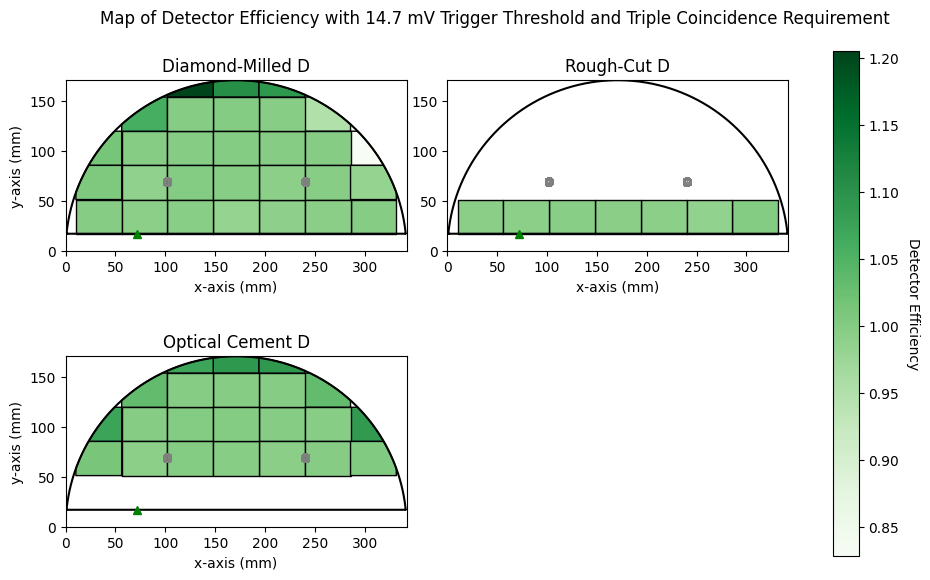

0.9835782195332757 1


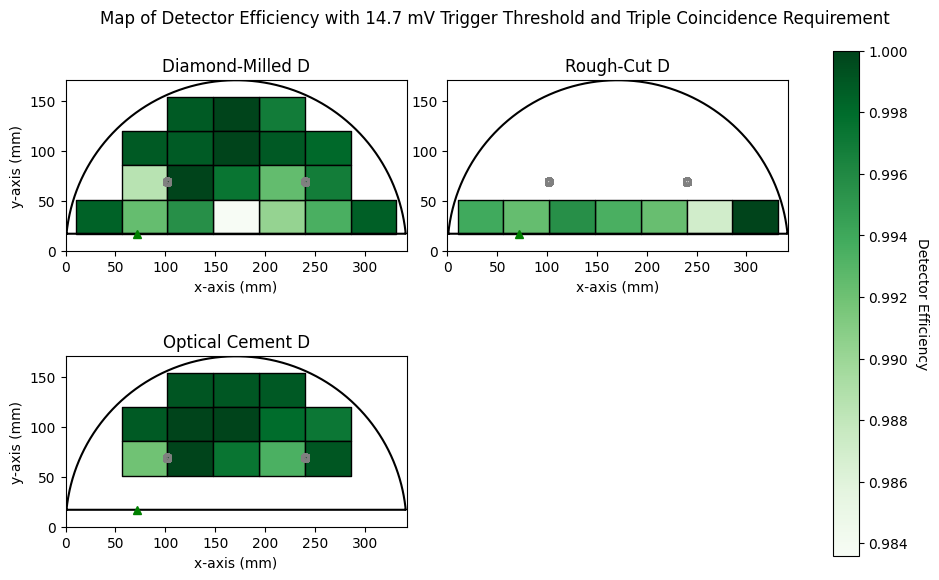

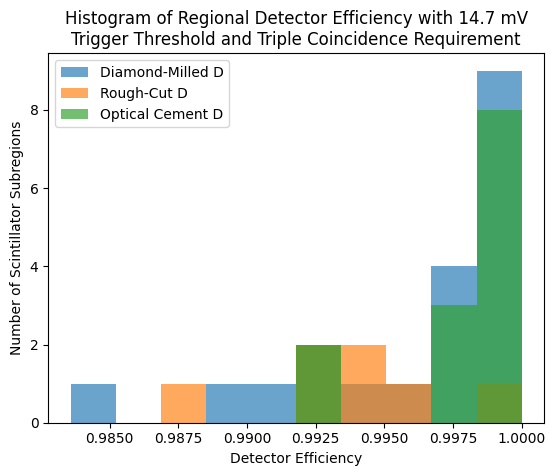

In [230]:
from copy import deepcopy
duration_dict,max_e_dict = {},{}
for key in data_dict.keys():
   test = data_dict[key][3]
   duration, e = test.duration, test.NEvents
   duration_dict[key] = duration
   # print(f"Weighting for {int(test.id)}: {old_box_data[int(test.id)]['weighting']*100:.2f}%")
   # max_e_dict[key] = e*old_box_data[int(test.id)]['weighting'] if int(test.id) < 60 else e
   max_e_dict[key] = e
   # if int(key) < 7: max_e_dict[key] *= 0.9562 # Reweighting of bottom row


de_list,e_list,er_list = [],[],[]
for ch in range(n_chs):
   de_dict,e_dict,er_dict = {},{},{}
   total_e,total_max_e = 0,0
   for key in data_dict.keys():
      test = data_dict[key][ch]
      duration,max_e = duration_dict[key],max_e_dict[key]
      e = test.NEvents
      if ch in [1,2]:
         # print('\n',key,ch)
         # print(f'Alpha = {alphas[int(key)][ch-1]}')
         # print(f'{e} --> {e+max_e*alphas[int(key)][ch-1]} (+{max_e*alphas[int(key)][ch-1]} events)')
         # print(f'{e/max_e} --> {(e+max_e*alphas[int(key)][ch-1])/max_e}')
         e += max_e*alphas[int(key)][ch-1]
      total_e += e
      total_max_e += max_e
      er = e/duration
      # print(f"Event Rate: {er}")
      # print(f"max_er: {max_er}")
      de = e/max_e
      # if ch in [1,2]: print(f'Channel {ch}: {round(e)} events seen out of {max_e} total ({de*100:.2f}%)')
      # print(f"Detector Efficiency: {de}")
      de_dict[int(key)] = de
      e_dict[int(key)] = e
      er_dict[int(key)] = er
   de_list.append(de_dict)
   e_list.append(e_dict)
   er_list.append(er_dict)
   # if ch in [1,2]: print(f'Channel {ch} has efficiency of {total_e/total_max_e*100:.4f}')

r1_dm, r1_rc = [val for k, val in de_list[1].items() if k<7],[val for k, val in de_list[2].items() if k<7]
rest_dm, rest_oc = [val for k, val in de_list[1].items() if k>=7],[val for k, val in de_list[2].items() if k>=7]
print(f'The average detector of the bottom row (diamond-milled) is {np.mean(r1_dm)}')
print(f'The average detector of the bottom row (rough_cut) is {np.mean(r1_rc)}')
print(f'The average detector of all other locations (diamond-milled) is {np.mean(rest_dm)}')
print(f'The average detector of all other locations (optical cement) is {np.mean(rest_oc)}')

interior_de_list = deepcopy(de_list)
for ch in interior_de_list:
   for key in list(ch.keys()):
      if key>=20 and key<60: ch.pop(key)
interior_old_box_data = old_box_data[:20]

print('\n --- Interior data ---')
r1_dm, r1_rc = [val for k, val in interior_de_list[1].items() if k<7],[val for k, val in interior_de_list[2].items() if k<7]
rest_dm, rest_oc = [val for k, val in interior_de_list[1].items() if k>=7],[val for k, val in interior_de_list[2].items() if k>=7]
print(f'The average detector of the bottom row (diamond-milled) is {np.mean(r1_dm)}')
print(f'The average detector of the bottom row (rough_cut) is {np.mean(r1_rc)}')
print(f'The average detector of all other locations (diamond-milled) is {np.mean(rest_dm)}')
print(f'The average detector of all other locations (optical cement) is {np.mean(rest_oc)}')

# make_rough_colour_map(er_list,old_box_data, [0,1,2,3], 'Test Map', 'Event Rate (events/s)', cmap = 'Greens')
# make_clean_colour_map(er_list,old_box_data,title='Map of Event Rate',cmap_label='Event Rate (events/s)',cmap='Greens')
# make_rough_colour_map(de_list,old_box_data, [0,1,2,3], 'Test Map', 'Detector Efficiency', cmap = 'Greens')
make_clean_colour_map(de_list,old_box_data,title='Map of Detector Efficiency with 14.7 mV Trigger Threshold and Triple Coincidence Requirement',cmap_label='Detector Efficiency',cmap='Greens')
make_clean_colour_map(interior_de_list,interior_old_box_data,title='Map of Detector Efficiency with 14.7 mV Trigger Threshold and Triple Coincidence Requirement',cmap_label='Detector Efficiency',cmap='Greens',vmax_override=1)

make_regional_hist(interior_de_list,'Histogram of Regional Detector Efficiency with 14.7 mV\nTrigger Threshold and Triple Coincidence Requirement','Detector Efficiency')

In [231]:
print(width)
print(height)
for err in range(1,5):
   err/=2
   print(f'\nIf we were off by {err} mm, we would see {100-err/height*100:.2f}% efficiency (scale up by {height/(height-err):.2f}x)')

print(f'\n\nEach -0.5 mm is a roughly -{0.5/height*100:.2f}% detector efficiency error')

print(f'{99.33/99.64} = 1 - x/{height}')
print(f'{(1-99.33/99.64)*height} mm')

45.92
34.28

If we were off by 0.5 mm, we would see 98.54% efficiency (scale up by 1.01x)

If we were off by 1.0 mm, we would see 97.08% efficiency (scale up by 1.03x)

If we were off by 1.5 mm, we would see 95.62% efficiency (scale up by 1.05x)

If we were off by 2.0 mm, we would see 94.17% efficiency (scale up by 1.06x)


Each -0.5 mm is a roughly -1.46% detector efficiency error
0.9968887996788438 = 1 - x/34.28
0.10665194700923432 mm


### Energy Peak

In [232]:
K_list, mu_list, sigma_list = [],[],[]
for ch in range(n_chs):
   K_dict, mu_dict, sigma_dict = {},{},{}
   if ch in [1,2]:
      for key in data_dict.keys():
         test = data_dict[key][ch]
         K,mu,sigma = test.get_EMG_params(plot=False)
         K_dict[int(key)] = K
         mu_dict[int(key)] = mu
         sigma_dict[int(key)] = sigma
   K_list.append(K_dict)
   mu_list.append(mu_dict)
   sigma_list.append(sigma_dict)

1.5952394185959242 15.472264540647574


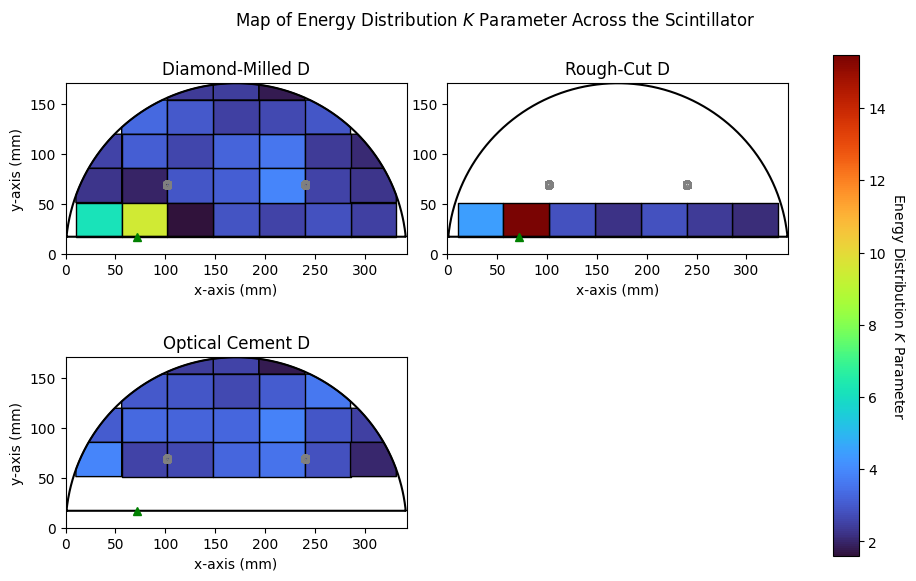

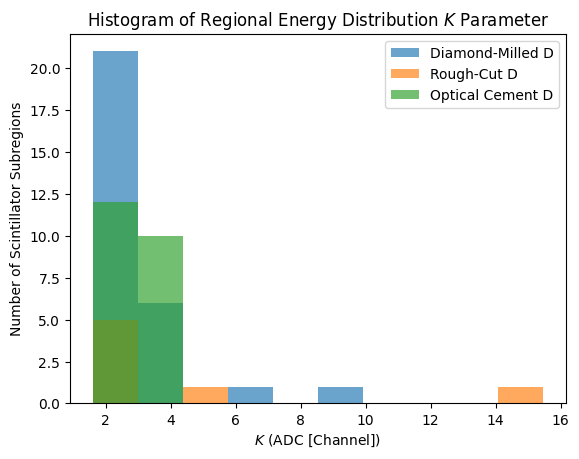

328.0121987784275 1459.0195431950108


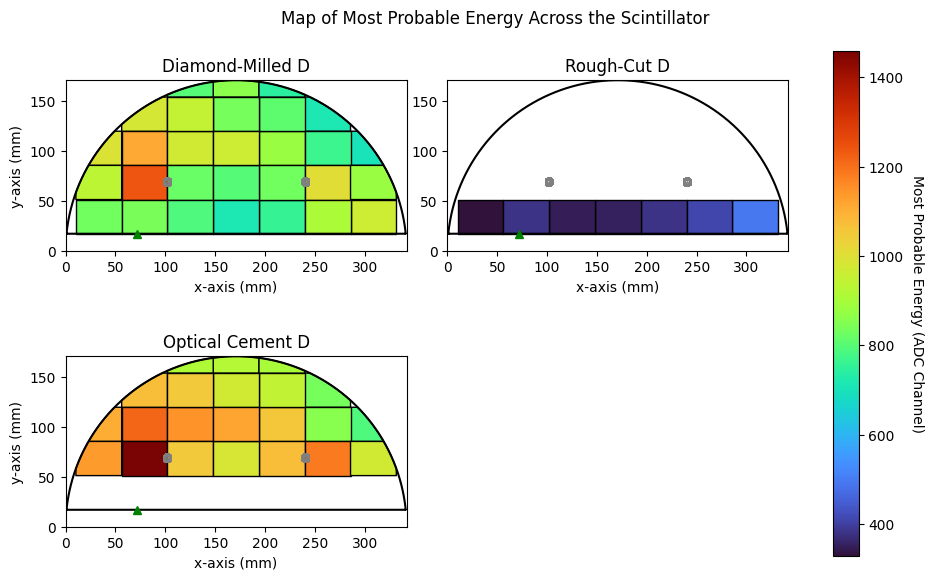

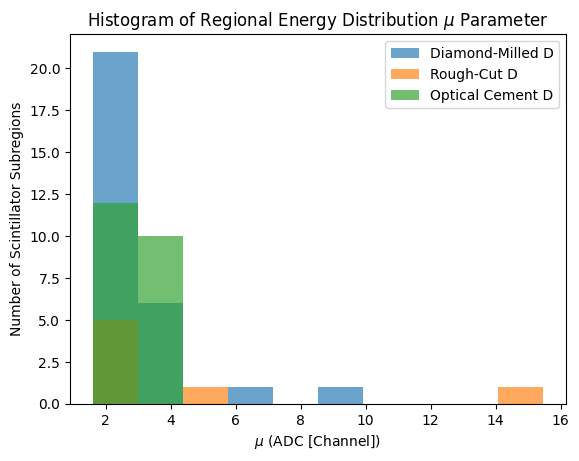

47.87061505340721 199.5833693934934


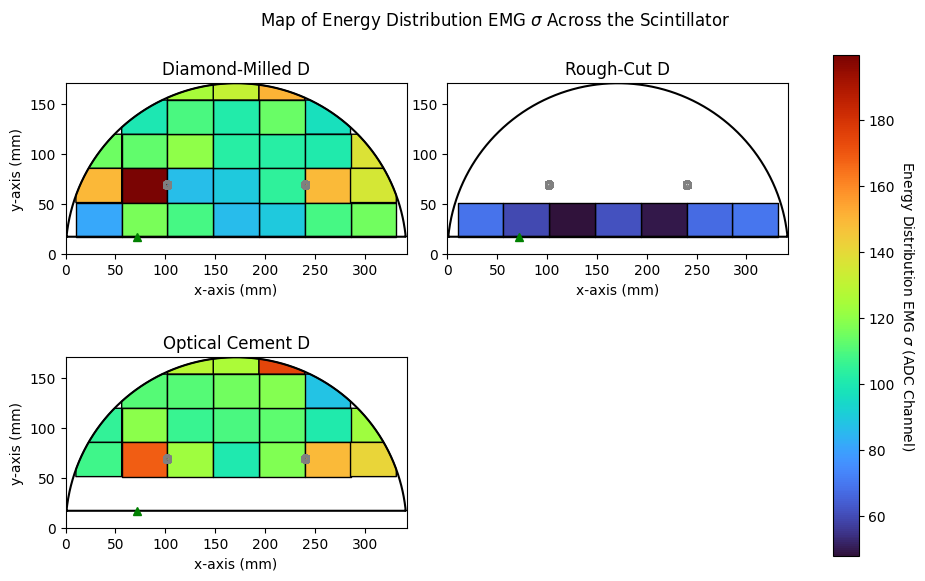

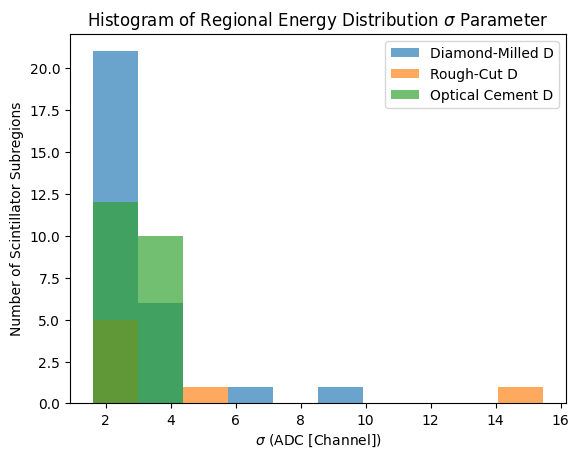

In [233]:
make_clean_colour_map(K_list,old_box_data, title='Map of Energy Distribution $K$ Parameter Across the Scintillator',cmap_label='Energy Distribution $K$ Parameter ')

make_regional_hist(K_list,'Histogram of Regional Energy Distribution $K$ Parameter', '$K$ (ADC [Channel])')

make_clean_colour_map(mu_list,old_box_data, title='Map of Most Probable Energy Across the Scintillator',cmap_label='Most Probable Energy (ADC Channel)')

make_regional_hist(K_list,r'Histogram of Regional Energy Distribution $\mu$ Parameter', r'$\mu$ (ADC [Channel])')

make_clean_colour_map(sigma_list,old_box_data, title=r'Map of Energy Distribution EMG $\sigma$ Across the Scintillator',cmap_label=r'Energy Distribution EMG $\sigma$ (ADC Channel)')

make_regional_hist(K_list,r'Histogram of Regional Energy Distribution $\sigma$ Parameter', r'$\sigma$ (ADC [Channel])')

### Timing Resolution

Idea taken from Sec 4.3 of Efficiency and timing resolution of scintillator tiles read out with silicon photomultipliers by Pooth et al. (2016). By fitting the time difference between two channels to a Gaussian, we can extract the average time difference and spread in time differences. Comparing this to two references (outer and inner scintillators) then allows us to do a little math to get the timing resolution. The width in times, $\sigma_t$ is given as
\begin{equation}
    \sigma_t = \sqrt{\sigma_{t,\mathrm{Det}}^2 - \sigma_{t,\mathrm{Ref}}^2}
\end{equation}
Thus, 
\begin{equation}
    \sigma_1 = \sqrt{\sigma_{t,\mathrm{Ref_1}}^2 - \sigma_{t,\mathrm{Ref_2}}^2}
\end{equation}

\begin{equation}
    \sigma_2 = \sqrt{\sigma_{t,\mathrm{Det}}^2 - \sigma_{t,\mathrm{Ref_1}}^2}
\end{equation}

\begin{equation}
    \sigma_3 = \sqrt{\sigma_{t,\mathrm{Det}}^2 - \sigma_{t,\mathrm{Ref_2}}^2}
\end{equation}
Combining these equations,
\begin{equation}
    \sigma_\mathrm{Det} = \sqrt{\frac{1}{2}(\sigma_1^2 + \sigma_2^2 + \sigma_3^2)}
\end{equation}
If there is an issue with the timing of Channel 0, we can just do channel 1 to channel 2 instead. This might be a nice idea for verification anyways.

dict_keys(['4', '13', '14', '22', '25', '1', '24', '23', '15', '12', '63', '62', '9', '7', '0', '8', '17', '28', '10', '26', '19', '21', '20', '27', '18', '11', '16', '6', '61', '5', '3', '2'])
dict_keys(['4', '13', '14', '22', '25', '1', '24', '23', '15', '12', '63', '62', '9', '7', '0', '8', '17', '28', '10', '26', '19', '21', '20', '27', '18', '11', '16', '6', '61', '5', '3', '2'])
dict_keys(['4', '13', '14', '22', '25', '1', '24', '23', '15', '12', '63', '62', '9', '7', '0', '8', '17', '28', '10', '26', '19', '21', '20', '27', '18', '11', '16', '6', '61', '5', '3', '2'])
dict_keys(['4', '13', '14', '22', '25', '1', '24', '23', '15', '12', '63', '62', '9', '7', '0', '8', '17', '28', '10', '26', '19', '21', '20', '27', '18', '11', '16', '6', '61', '5', '3', '2'])


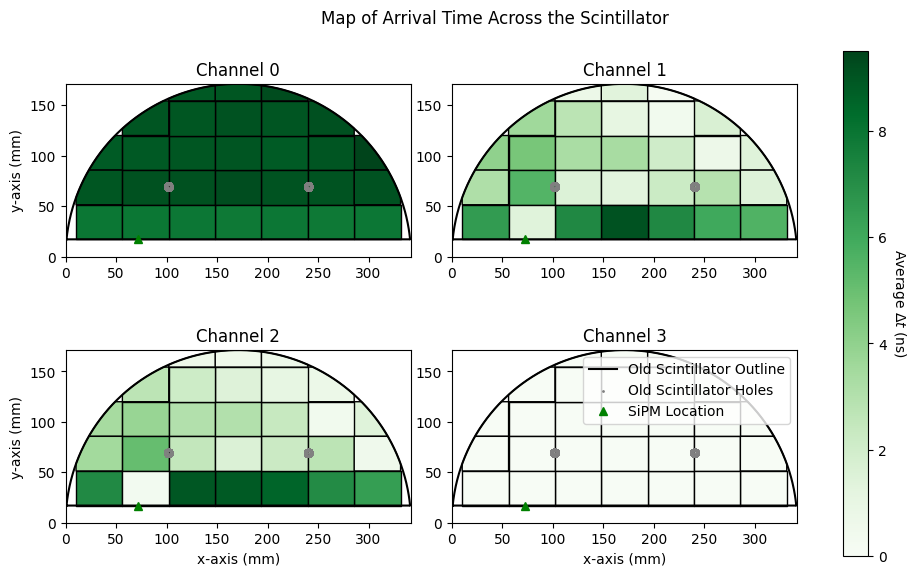

0 9.50963451922022


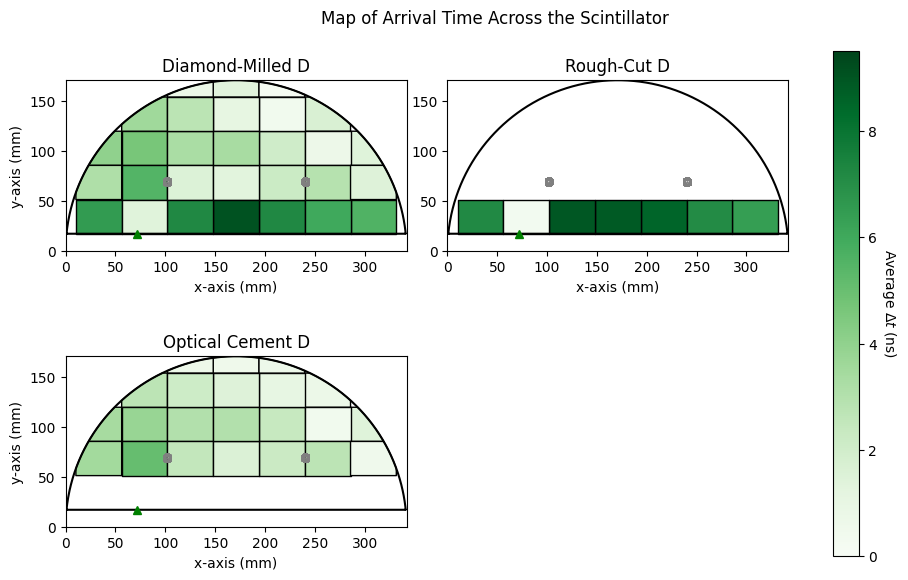

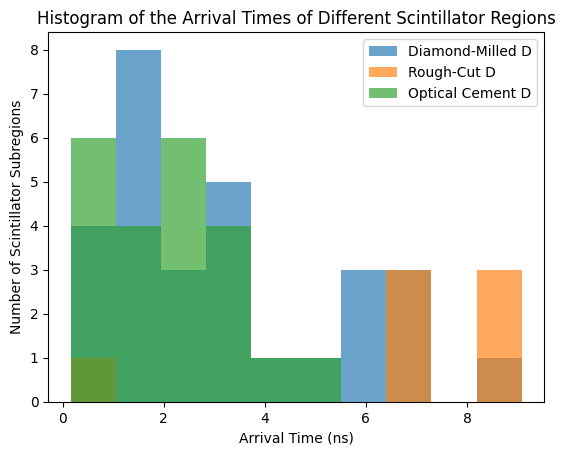

In [234]:
def compare_timing(ref_i,d_dict,display=False):
   print(d_dict.keys())
   ref_t_dict = {}
   for key in d_dict.keys():
      # print(d_dict[key])
      test = d_dict[key][ref_i]
      t = test.nmt
      ref_t_dict[key] = t

   mu_t_list,sigma_t_list = [],[]
   for ch in range(n_chs):
      if display: print(f"Channel {ch}")
      mu_t_dict,sigma_t_dict = {},{}
      for key in d_dict.keys():
         if ch == ref_i:
            mu_t_dict[int(key)] = 0
            sigma_t_dict[int(key)] = 0
            if display: print(f"{key} - μ: {0.0} ns, σ: {0.0} ns")
         else:
            test = d_dict[key][ch]
            ref_t = ref_t_dict[key]
            mu, sigma = test.get_dt_params(ref_t,plot=False) if not display else test.get_dt_params(ref_t,plot=True)
            mu_t_dict[int(key)] = np.abs(mu) # Convert to ns
            sigma_t_dict[int(key)] = sigma # Convert to ns
            if display: print(f"{key} - μ: {mu:.6f} ns, σ: {sigma:.6f} ns")
      mu_t_list.append(mu_t_dict)
      sigma_t_list.append(sigma_t_dict)

   return mu_t_list, sigma_t_list

# print(data_dict)
mu_0_list,sigma_0_list = compare_timing(0,data_dict)
mu_1_list,sigma_1_list = compare_timing(1,data_dict)
mu_2_list,sigma_2_list = compare_timing(2,data_dict)
mu_3_list,sigma_3_list = compare_timing(3,data_dict)

# make_colour_map(mu_0_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 0 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(mu_1_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 1 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(mu_2_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 2 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(mu_3_list,old_box_data, [0,1,2,3], 'Map of Average Time Difference Between Channel 3 Trigger', r'Average $\Delta t$ (ns)', cmap = 'coolwarm')
# make_colour_map(sigma_3_list,old_box_data, [0,1,2,3], 'Standard Deviation Test Map', r'Standard Deviation of $\Delta t$ (ns)', cmap = 'coolwarm')
make_rough_colour_map(mu_3_list,old_box_data, [0,1,2,3], 'Map of Arrival Time Across the Scintillator', r'Average $\Delta t$ (ns)', cmap = 'Greens')
make_clean_colour_map(mu_3_list,old_box_data, title='Map of Arrival Time Across the Scintillator', cmap_label=r'Average $\Delta t$ (ns)', cmap = 'Greens')

make_regional_hist(mu_3_list,'Histogram of the Arrival Times of Different Scintillator Regions', 'Arrival Time (ns)')

\begin{equation}
    \sigma_{03} = \sqrt{\sigma_{t,\mathrm{~Channel~0}}^2 + \sigma_{t,\mathrm{~Channel~3}}^2}
\end{equation}

\begin{equation}
    \sigma_{10} = \sqrt{\sigma_{t,\mathrm{~Channel~1}}^2 + \sigma_{t,\mathrm{~Channel~0}}^2}
\end{equation}

\begin{equation}
    \sigma_{13} = \sqrt{\sigma_{t,\mathrm{~Channel~1}}^2 + \sigma_{t,\mathrm{~Channel~3}}^2}
\end{equation}

And finally,

\begin{equation}
    \sigma_\mathrm{Channel~1} = \sqrt{\frac{1}{2}(\sigma_{10}^2 + \sigma_{13}^2 - \sigma_{03}^2)}
\end{equation}

\begin{equation}
    \sigma_\mathrm{Channel~2} = \sqrt{\frac{1}{2}(\sigma_{20}^2 + \sigma_{23}^2 - \sigma_{03}^2)}
\end{equation}

dict_keys(['4', '13', '14', '22', '25', '1', '24', '23', '15', '12', '63', '62', '9', '7', '0', '8', '17', '28', '10', '26', '19', '21', '20', '27', '18', '11', '16', '6', '61', '5', '3', '2'])
dict_keys([4, 13, 14, 22, 25, 1, 24, 23, 15, 12, 63, 62, 9, 7, 0, 8, 17, 28, 10, 26, 19, 21, 20, 27, 18, 11, 16, 6, 61, 5, 3, 2])
4
1.0057232931487885 5.746038401745181


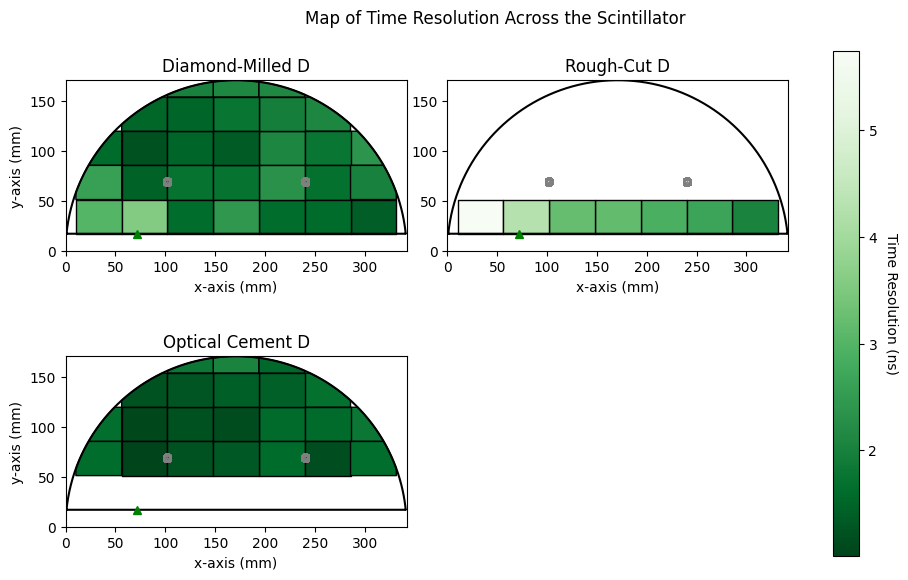

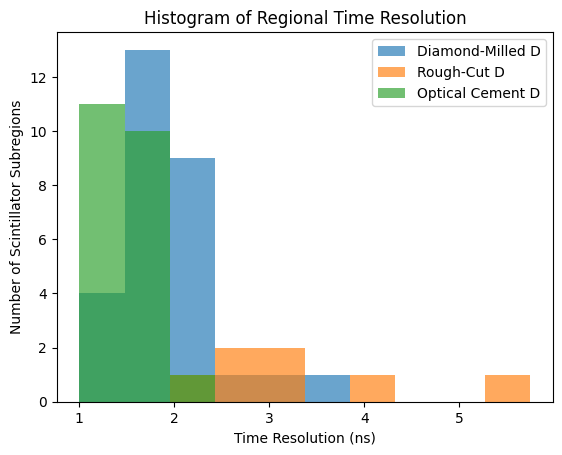

In [235]:
sig1,sig2 = {},{}
print(data_dict.keys())
for key in data_dict.keys():
   key = int(key)
   sig03 = sigma_3_list[0][key]
   sig10 = sigma_0_list[1][key]
   sig20 = sigma_0_list[2][key]
   sig13 = sigma_3_list[1][key]
   sig23 = sigma_3_list[2][key]
   # print(sig10,sig13,sig03)
   sig1[int(key)] = np.sqrt(0.5*(sig10**2+sig13**2-sig03**2))
   sig2[int(key)] = np.sqrt(0.5*(sig20**2+sig23**2-sig03**2))
time_res_list = [{},sig1,sig2,{}]
print(sig1.keys())
print(len(time_res_list))

make_clean_colour_map(time_res_list,old_box_data, title='Map of Time Resolution Across the Scintillator', cmap_label='Time Resolution (ns)', cmap = 'Greens_r')
make_regional_hist(time_res_list,'Histogram of Regional Time Resolution', 'Time Resolution (ns)')

### Other Plot Making

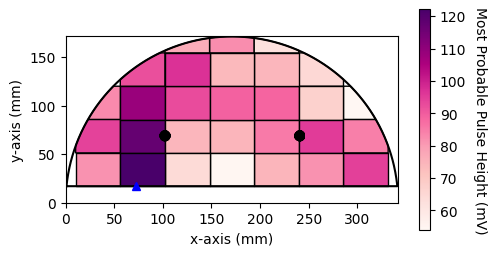

In [279]:
plt.figure(figsize=(5,2.5))

# plt.title('Most Probable Pulse Height')
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
box_values = ph_mpv_list[1]

box_positions = {}
for key in box_values.keys():
   if key in range(len(old_box_data)):
      corner = old_box_data[key]['xy']
      box_positions[key] = (float(corner[0]),float(corner[1]))

patch_list = []
values = []
for box_id, (x, y) in box_positions.items():
   if box_id in box_values:
      # Create a rectangle patch for the box
      shapely_poly = old_scint_shape_wout_holes.intersection(box(x,y,x+width,y+height))
      mpl_poly = ptch.Polygon(shapely_poly.exterior.coords, closed=True, facecolor='blue')
      patch_list.append(mpl_poly)
      values.append(box_values[box_id])

p_collection = PatchCollection(patch_list, cmap='RdPu', edgecolor='black', linewidth=1)
p_collection.set_array(np.array(values))
ax = plt.gca()
ax.add_collection(p_collection)

plt.plot(old_scint[0], old_scint[1], color='black')
plt.scatter(holes[0], holes[1], s=2, color='black')
plt.plot(SiPM_loc[0],SiPM_loc[1],color='blue',linestyle='',marker='^')
plt.xlim(0,342)
plt.ylim(0,171)
ax.set_aspect('equal')

plt.tight_layout()
cbar = plt.colorbar(p_collection, ax=ax, shrink=1.25)
cbar.set_label('Most Probable Pulse Height (mV)', rotation=270, labelpad=15)
# plt.legend()
plt.show()

'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r'

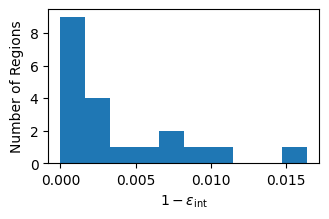

In [286]:
import matplotlib.ticker as mticker

mod_interior_de_list = [{},{},{},{}]
for ch in range(4):
   for key in interior_de_list[ch].keys():
      de = interior_de_list[ch][key]
      mod_interior_de_list[ch][key] = 1-de

plt.figure(figsize=(3.5,2))
dm = {k: val for k, val in mod_interior_de_list[1].items() if int(k)<60}.values()
_,bins = np.histogram(list(dm))
plt.xlabel(r'$1 - \epsilon_\mathrm{int}$')
plt.ylabel('Number of Regions')
plt.hist(dm,bins=bins)
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.3f}'))
plt.show()

In [ ]:
plt.figure(figsize=(5,2.5))

# plt.title('Most Probable Pulse Height')
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
box_values = ph_mpv_list[1]

box_positions = {}
for key in box_values.keys():
   if key in range(len(old_box_data)):
      corner = old_box_data[key]['xy']
      box_positions[key] = (float(corner[0]),float(corner[1]))

patch_list = []
values = []
for box_id, (x, y) in box_positions.items():
   if box_id in box_values:
      # Create a rectangle patch for the box
      shapely_poly = old_scint_shape_wout_holes.intersection(box(x,y,x+width,y+height))
      mpl_poly = ptch.Polygon(shapely_poly.exterior.coords, closed=True, facecolor='blue')
      patch_list.append(mpl_poly)
      values.append(box_values[box_id])

p_collection = PatchCollection(patch_list, cmap='RdPu', edgecolor='black', linewidth=1)
p_collection.set_array(np.array(values))
ax = plt.gca()
ax.add_collection(p_collection)

plt.plot(old_scint[0], old_scint[1], color='black')
plt.scatter(holes[0], holes[1], s=2, color='black')
plt.plot(SiPM_loc[0],SiPM_loc[1],color='blue',linestyle='',marker='^')
plt.xlim(0,342)
plt.ylim(0,171)
ax.set_aspect('equal')

plt.tight_layout()
cbar = plt.colorbar(p_collection, ax=ax, shrink=1.25)
cbar.set_label(r'$1 - \epsilon_\mathrm{int}$', rotation=270, labelpad=15)
# plt.legend()
plt.show()

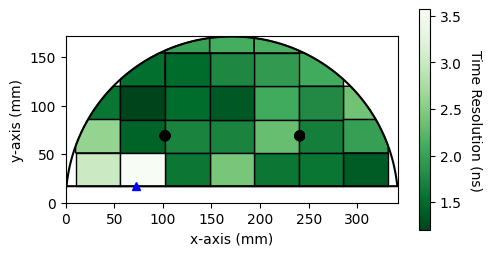

In [278]:
plt.figure(figsize=(5,2.5))

# plt.title('Most Probable Pulse Height')
plt.xlabel('x-axis (mm)')
plt.ylabel('y-axis (mm)')
box_values = time_res_list[1]

box_positions = {}
for key in box_values.keys():
   if key in range(len(old_box_data)):
      corner = old_box_data[key]['xy']
      box_positions[key] = (float(corner[0]),float(corner[1]))

patch_list = []
values = []
for box_id, (x, y) in box_positions.items():
   if box_id in box_values:
      # Create a rectangle patch for the box
      shapely_poly = old_scint_shape_wout_holes.intersection(box(x,y,x+width,y+height))
      mpl_poly = ptch.Polygon(shapely_poly.exterior.coords, closed=True, facecolor='blue')
      patch_list.append(mpl_poly)
      values.append(box_values[box_id])

p_collection = PatchCollection(patch_list, cmap='Greens_r', edgecolor='black', linewidth=1)
p_collection.set_array(np.array(values))
ax = plt.gca()
ax.add_collection(p_collection)

plt.plot(old_scint[0], old_scint[1], color='black')
plt.scatter(holes[0], holes[1], s=2, color='black')
plt.plot(SiPM_loc[0],SiPM_loc[1],color='blue',linestyle='',marker='^')
plt.xlim(0,342)
plt.ylim(0,171)
ax.set_aspect('equal')

plt.tight_layout()
cbar = plt.colorbar(p_collection, ax=ax, shrink=1.25)
cbar.set_label('Time Resolution (ns)', rotation=270, labelpad=15)
# plt.legend()
plt.show()

In [ ]:
def error_estimate(chs, start,stop,lst_of_vals,dtype):
   # print(len(lst_of_vals))
   start+=61
   stop+=61
   print(f"\n--- ERROR ESTIMATE ({dtype}) ---")
   for ch in chs:
      lst_6x = []
      # print(ch,lst_of_vals[ch].keys())
      for xx in range(start,stop):
         lst_6x.append(lst_of_vals[ch][xx])
      print(lst_6x)
      print(f'Channel {ch}: Mean - {np.mean(lst_6x):.4f}, Std - {np.std(lst_6x):.4f}   ({np.std(lst_6x)/np.mean(lst_6x)*100:.2f}%)')

error_estimate([0,1,2,3],0,3,ph_mpv_list,'Pulse Height')
error_estimate([1,2],0,3,time_res_list,'Time Resolution')
error_estimate([0,1,2,3],0,3,mod_interior_de_list,'Detector Efficiency')


--- ERROR ESTIMATE (Pulse Height) ---
[np.float64(128.0795318231593), np.float64(132.17255776128295), np.float64(193.5784155109328)]
Channel 0: Mean - 151.2768, Std - 29.9584   (19.80%)
[np.float64(73.53897894550043), np.float64(69.4434759221874), np.float64(54.30440098930617)]
Channel 1: Mean - 65.7623, Std - 8.2727   (12.58%)
[np.float64(88.03273001645036), np.float64(80.49463934283791), np.float64(29.561958953017182)]
Channel 2: Mean - 66.0298, Std - 25.9696   (39.33%)
[np.float64(268.2372699729931), np.float64(313.5933824058188), np.float64(265.73625390563353)]
Channel 3: Mean - 282.5223, Std - 21.9943   (7.78%)

--- ERROR ESTIMATE (Time Resolution) ---
[np.float64(1.655283979301092), np.float64(1.8036226587412503), np.float64(2.4210318709637404)]
Channel 1: Mean - 1.9600, Std - 0.3316   (16.92%)
[np.float64(1.2155759419073868), np.float64(1.3943107062198057), np.float64(3.179417692961386)]
Channel 2: Mean - 1.9298, Std - 0.8866   (45.95%)

--- ERROR ESTIMATE (Detector Efficiency)